In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
mainfolder = '/content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/03-pythons2026-junio/'

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec

import os
import joblib  # to save the scaler

from numba import njit # for the LQ mass reconstruction

from scipy.optimize import fsolve, minimize
from scipy import stats
from scipy.stats import poisson
from scipy.stats import ks_2samp
from scipy.stats import anderson_ksamp
from scipy.stats import wasserstein_distance
from scipy.stats import chisquare
from scipy.interpolate import interp1d

import math
import random

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Conv2D, Flatten, MaxPooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn import preprocessing
from sklearn.metrics import roc_curve, roc_auc_score, auc, accuracy_score
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor, XGBClassifier
import xgboost as xgb

# LOAD DATA

## Background

In [5]:
CHs_selected = ["tt", "singletP1", "singletP2", "Wbbjets", "ttW", "ttZ", "ttH"]


df_B_all = {}
X_B_all = {}


output_folder = mainfolder + "../DATA/backgrounds/data_df/"

for CH_sel in CHs_selected:
    # Read the file
    if CH_sel == 'singletP2':
        filename = mainfolder + '../DATA-wjets/backgrounds/dats-singlet-comp/df_' + CH_sel + ".csv"
    else:
        filename = mainfolder + '../DATA-wjets/backgrounds/dats-' + CH_sel + '/df_' + CH_sel + ".csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_B_all[CH_sel] = df_temp
    X_B_all[CH_sel] = df_temp[feats_label].values

    # Print
    print(f"X_{CH_sel}.shape: {X_B_all[CH_sel].shape}")

X_tt.shape: (826022, 53)
X_singletP1.shape: (179677, 53)
X_singletP2.shape: (94219, 53)
X_Wbbjets.shape: (162448, 53)
X_ttW.shape: (141919, 53)
X_ttZ.shape: (16178, 53)
X_ttH.shape: (12068, 53)


## Signal SLQ

In [6]:
masses_SLQ = [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2200]
masses_SLQ = [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]


df_SLQ_all = {}
X_SLQ_all = {}


output_folder = mainfolder + "../DATA/signal/data_df/"

for mass_sel in masses_SLQ:
    # Read the file
    filename = mainfolder + '../DATA-wjets/signals/dats-SLQ-' + str(mass_sel) + 'GeV/df_SLQ_' + str(mass_sel) + "GeV.csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_SLQ_all[mass_sel] = df_temp
    X_SLQ_all[mass_sel] = df_temp[feats_label].values

    # Print
    print(f"X_SLQ_{mass_sel}GeV.shape: {X_SLQ_all[mass_sel].shape}")

X_SLQ_1000GeV.shape: (267452, 53)
X_SLQ_1100GeV.shape: (271062, 53)
X_SLQ_1200GeV.shape: (534247, 53)
X_SLQ_1300GeV.shape: (196510, 53)
X_SLQ_1400GeV.shape: (506381, 53)
X_SLQ_1500GeV.shape: (185940, 53)
X_SLQ_1600GeV.shape: (481827, 53)
X_SLQ_1700GeV.shape: (173573, 53)
X_SLQ_1800GeV.shape: (301687, 53)
X_SLQ_1900GeV.shape: (64690, 53)


## Signal VLQ

In [7]:
masses_VLQ = [1200, 1500, 1400, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]
masses_VLQ = [1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]


df_VLQ_all = {}
X_VLQ_all = {}


output_folder = mainfolder + "../DATA/signal/data_df/"

for mass_sel in masses_VLQ:
    # Read the file
    filename = mainfolder + '../DATA-wjets/signals/dats-VLQ-' + str(mass_sel) + 'GeV/df_VLQ_' + str(mass_sel) + "GeV.csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_VLQ_all[mass_sel] = df_temp
    X_VLQ_all[mass_sel] = df_temp[feats_label].values

    # Print
    print(f"X_VLQ_{mass_sel}GeV.shape: {X_VLQ_all[mass_sel].shape}")

X_VLQ_1400GeV.shape: (139696, 53)
X_VLQ_1500GeV.shape: (293700, 53)
X_VLQ_1600GeV.shape: (134774, 53)
X_VLQ_1700GeV.shape: (192819, 53)
X_VLQ_1800GeV.shape: (127670, 53)
X_VLQ_1900GeV.shape: (75898, 53)
X_VLQ_2000GeV.shape: (184097, 53)
X_VLQ_2100GeV.shape: (72762, 53)
X_VLQ_2200GeV.shape: (232166, 53)
X_VLQ_2300GeV.shape: (64705, 53)


# Cross Section

In [8]:
Lum = 3000

In [9]:
# -------------------------
# cross sections
# -------------------------
k_LQ = 1.8877462860822058

xsec_file_14TeV = mainfolder + '../DATA-wjets/signals/LQs-xsec-14TeV.txt'

xsec_data_14TeV = np.loadtxt(xsec_file_14TeV, comments='#')

# columns: 0=mass, 1=SLQ, 2=VLQ
masses_14TeV = xsec_data_14TeV[:,0].astype(int)
fidxsec_SLQ_14TeV = dict(zip(masses_14TeV, xsec_data_14TeV[:,1]*k_LQ))
fidxsec_VLQ_14TeV = dict(zip(masses_14TeV, xsec_data_14TeV[:,2]*k_LQ))


masses_SLQ_14TeV = [1200, 1400, 1600, 1800, 2000, 2200]
masses_VLQ_14TeV = [1200, 1400, 1600, 1800, 2000, 2200]

fidxsec_SLQ_non0_14TeV = [fidxsec_SLQ_14TeV[ii] for ii in masses_SLQ_14TeV]
fidxsec_VLQ_non0_14TeV = [fidxsec_VLQ_14TeV[ii] for ii in masses_VLQ_14TeV]


#  interpolate
f_xsec_SLQ_log_14TeV = interp1d(masses_SLQ_14TeV, np.log10(fidxsec_SLQ_non0_14TeV), kind='linear', fill_value="extrapolate")
f_xsec_VLQ_log_14TeV = interp1d(masses_VLQ_14TeV, np.log10(fidxsec_VLQ_non0_14TeV), kind='linear', fill_value="extrapolate")



# -------------------------
# cross sections
# -------------------------
xsec_file_betas_14TeV = mainfolder + '../DATA-wjets/signals/LQs-xsec-14TeV-betas.txt'

xsec_data_betas_14TeV = np.loadtxt(xsec_file_betas_14TeV, comments='#')

# columns: 0=beta, 1,...=SLQ, -1=ratio=fid_xsec(beta)/fid_xsec(beta=0.5)
betas = xsec_data_betas_14TeV[:,0]
ratio_mean_14TeV = xsec_data_betas_14TeV[:,-1]

#  interpolate
f_ratio_SLQ_log_14TeV = interp1d(betas, ratio_mean_14TeV, kind='linear', fill_value="extrapolate")
f_ratio_VLQ_log_14TeV = interp1d(betas, ratio_mean_14TeV, kind='linear', fill_value="extrapolate")



# FINAL FUNCTIONS
def fid_xsec_SLQ_14TeV(mass, beta):
    return 10**f_xsec_SLQ_log_14TeV(mass) * f_ratio_SLQ_log_14TeV(beta)

def fid_xsec_VLQ_14TeV(mass, beta):
    return 10**f_xsec_VLQ_log_14TeV(mass) * f_ratio_VLQ_log_14TeV(beta)

In [10]:
masses = [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]

beta = 0.9

fidxsec_SLQ = dict(zip(masses, fid_xsec_SLQ_14TeV(masses, beta)))
fidxsec_VLQ = dict(zip(masses, fid_xsec_VLQ_14TeV(masses, beta)))


print('masses: ', masses)
print(fidxsec_SLQ[1200], '[fb]')
print(fidxsec_VLQ[1600], '[fb]')

masses:  [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]
0.21532724870974246 [fb]
0.2308148332537432 [fb]


In [11]:
# -----------------------------------
# LQs number and fid cross sections
# -----------------------------------


for m_it in masses_SLQ:
    print(f"# eventos SLQ {m_it} GeV:", len(X_SLQ_all[m_it]), "  fid_xsec = ", fidxsec_SLQ[m_it], "[fb]")

print(" ")
for m_it in masses_VLQ:
    print(f"# eventos VLQ {m_it} GeV:", len(X_VLQ_all[m_it]), "  fid_xsec = ", fidxsec_VLQ[m_it], "[fb]")

# eventos SLQ 1000 GeV: 267452   fid_xsec =  0.6743370925478925 [fb]
# eventos SLQ 1100 GeV: 271062   fid_xsec =  0.3810553120496612 [fb]
# eventos SLQ 1200 GeV: 534247   fid_xsec =  0.21532724870974246 [fb]
# eventos SLQ 1300 GeV: 196510   fid_xsec =  0.12167741157447672 [fb]
# eventos SLQ 1400 GeV: 506381   fid_xsec =  0.06875763553465554 [fb]
# eventos SLQ 1500 GeV: 185940   fid_xsec =  0.03987182784060728 [fb]
# eventos SLQ 1600 GeV: 481827   fid_xsec =  0.023121252541468598 [fb]
# eventos SLQ 1700 GeV: 173573   fid_xsec =  0.013392035146050679 [fb]
# eventos SLQ 1800 GeV: 301687   fid_xsec =  0.007756785884821487 [fb]
# eventos SLQ 1900 GeV: 64690   fid_xsec =  0.004578050555081722 [fb]
 
# eventos VLQ 1400 GeV: 139696   fid_xsec =  0.6945021612322532 [fb]
# eventos VLQ 1500 GeV: 293700   fid_xsec =  0.4003765734145628 [fb]
# eventos VLQ 1600 GeV: 134774   fid_xsec =  0.2308148332537432 [fb]
# eventos VLQ 1700 GeV: 192819   fid_xsec =  0.13522195571730963 [fb]
# eventos VLQ 1800 G

In [12]:
# FOR 14 TeV

k_fakett = 1.1053030485310749
crossfid_fakett = 0.244
k_tt = 1.2593273872014419
crossfid_tt = (7.74198*k_tt) + (crossfid_fakett * k_fakett)


fidxsec_SM = {'tt': crossfid_tt,
              'singletP1': 0.632632 * 3.440676833094312,
              'singletP2': 0.3182704 * 3.440676833094312,
              'Wbbjets': 1.6542420183645095 * 0.9781509289273502,
              'ttW': 0.03683196 * 3.056401327463198,
              'ttZ': 0.0715444 * 3.056401327463198,
              'ttH': 0.03630132 * 2.2127445612386474
              }

for ch_it in fidxsec_SM:
    print(f"# eventos {ch_it}:", len(X_B_all[ch_it]), "  fid_xsec = ", fidxsec_SM[ch_it], "[fb]")

# eventos tt: 826022   fid_xsec =  10.019381389007401 [fb]
# eventos singletP1: 179677   fid_xsec =  2.1766822662741205 [fb]
# eventos singletP2: 94219   fid_xsec =  1.09506559193966 [fb]
# eventos Wbbjets: 162448   fid_xsec =  1.6180983669338997 [fb]
# eventos ttW: 141919   fid_xsec =  0.1125732514370714 [fb]
# eventos ttZ: 16178   fid_xsec =  0.218668399132558 [fb]
# eventos ttH: 12068   fid_xsec =  0.08032554839578374 [fb]


In [13]:
# MAX SM dataset
totalcrossSM = sum([fidxsec_SM[ch_it] for ch_it in fidxsec_SM])


weigth_gen_SM = {}

for ch_it in fidxsec_SM:

    print(f"fraction of {ch_it}:", fidxsec_SM[ch_it] / totalcrossSM )

    weigth_gen_SM[ch_it] = len(X_B_all[ch_it]) / (fidxsec_SM[ch_it] / totalcrossSM)

print('\nchannel limiting the SM background: ', min(weigth_gen_SM, key=weigth_gen_SM.get) , '\n')


max_evs_SM = {}

for ch_it in fidxsec_SM:
    max_evs_SM[ch_it] = round( min(weigth_gen_SM.values()) * (fidxsec_SM[ch_it] / totalcrossSM) )
    print(f"# eventos {ch_it} (max):", max_evs_SM[ch_it])

max_SM_dataset = sum(max_evs_SM.values())
print('\nmax SM dataset length: ', max_SM_dataset )

fraction of tt: 0.6539726894865112
fraction of singletP1: 0.14207371698562551
fraction of singletP2: 0.07147576906400852
fraction of Wbbjets: 0.10561451848099845
fraction of ttW: 0.0073477422555561795
fraction of ttZ: 0.014272653723245071
fraction of ttH: 0.005242910004055022

channel limiting the SM background:  ttZ 

# eventos tt (max): 741276
# eventos singletP1 (max): 161040
# eventos singletP2 (max): 81018
# eventos Wbbjets (max): 119714
# eventos ttW (max): 8329
# eventos ttZ (max): 16178
# eventos ttH (max): 5943

max SM dataset length:  1133498


## Number of events to get a balanced dataset

In [14]:
# -------------------------
# Step 1: minimim number of events in LQs (selected mass)
# -------------------------

num_data_SLQ = [len(X_SLQ_all[m_it]) for m_it in masses_SLQ]

num_data_VLQ = [len(X_VLQ_all[m_it]) for m_it in masses_VLQ]


max_SM_dataset = min(1000000, max_SM_dataset)

num_data_NP = min(int(max_SM_dataset / (len(masses_SLQ) + len(masses_VLQ))) , min(num_data_SLQ + num_data_VLQ) )

print('SIGNAL: # events per-class chosen =', num_data_NP)



# -------------------------
# Step 2: background total fid_xsec
# -------------------------
totalcrossSM = sum([fidxsec_SM[ch_it] for ch_it in fidxsec_SM])



# -------------------------
# Step 3: number of events per chanel, proportional to xsec
# -------------------------
num_data_SM_dict = {}
for ch_it in fidxsec_SM:
    if ch_it == 'tt':
        # set at the end to have exactly the same # events (otherwise can be a difference of 1 due to rounding)
        continue
    fraction = fidxsec_SM[ch_it]/totalcrossSM
    num_data_SM_dict[ch_it] = round(num_data_NP * fraction * (len(masses_SLQ) + len(masses_VLQ)) )

# Set tt such that the total matches num_data_NP
num_data_SM_dict['tt'] = num_data_NP * (len(masses_SLQ) + len(masses_VLQ)) - sum([v for k,v in num_data_SM_dict.items() if k != 'tt'])




print('\nBACKGROUND events chosen (weighted by xsec):')
for ch_it in fidxsec_SM:
    print(f'# {ch_it}: {num_data_SM_dict[ch_it]}')
print('# total B events chosen: ', sum(num_data_SM_dict.values()))

SIGNAL: # events per-class chosen = 50000

BACKGROUND events chosen (weighted by xsec):
# tt: 653971
# singletP1: 142074
# singletP2: 71476
# Wbbjets: 105615
# ttW: 7348
# ttZ: 14273
# ttH: 5243
# total B events chosen:  1000000


In [15]:
# keep just the events needed

for m_it in masses_SLQ:
    X_SLQ_all[m_it] = X_SLQ_all[m_it][:num_data_NP]
    df_SLQ_all[m_it] = df_SLQ_all[m_it][:num_data_NP]

print(" ")
for m_it in masses_VLQ:
    X_VLQ_all[m_it] = X_VLQ_all[m_it][:num_data_NP]
    df_VLQ_all[m_it] = df_VLQ_all[m_it][:num_data_NP]

print("")
for ch_it in fidxsec_SM:
    X_B_all[ch_it] = X_B_all[ch_it][:num_data_SM_dict[ch_it]]
    df_B_all[ch_it] = df_B_all[ch_it][:num_data_SM_dict[ch_it]]

In [16]:
B_expected = round(Lum * totalcrossSM)    # luminosity * cross * aceptance
print('B_expected: ', B_expected)

for ch_it in fidxsec_SM:
    print(f" channel {ch_it}:", "  fid_xsec = ", fidxsec_SM[ch_it], "[fb]", " B_exp_ch: ", round(Lum * fidxsec_SM[ch_it]) )



S_expected_SLQ = []

for m_it in masses_SLQ:
    S_expected_SLQ.append( round(Lum * fidxsec_SLQ[m_it]) )

print('\nmasses:           ', masses_SLQ)
print('S_expected (SLQ): ', S_expected_SLQ)    # luminosity * cross * aceptance



S_expected_VLQ = []

for m_it in masses_VLQ:
    S_expected_VLQ.append( round(Lum * fidxsec_VLQ[m_it]) )

print('\nmasses:           ', masses_VLQ)
print('S_expected (VLQ): ', S_expected_VLQ)    # luminosity * cross * aceptance

B_expected:  45962
 channel tt:   fid_xsec =  10.019381389007401 [fb]  B_exp_ch:  30058
 channel singletP1:   fid_xsec =  2.1766822662741205 [fb]  B_exp_ch:  6530
 channel singletP2:   fid_xsec =  1.09506559193966 [fb]  B_exp_ch:  3285
 channel Wbbjets:   fid_xsec =  1.6180983669338997 [fb]  B_exp_ch:  4854
 channel ttW:   fid_xsec =  0.1125732514370714 [fb]  B_exp_ch:  338
 channel ttZ:   fid_xsec =  0.218668399132558 [fb]  B_exp_ch:  656
 channel ttH:   fid_xsec =  0.08032554839578374 [fb]  B_exp_ch:  241

masses:            [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]
S_expected (SLQ):  [2023, 1143, 646, 365, 206, 120, 69, 40, 23, 14]

masses:            [1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]
S_expected (VLQ):  [2084, 1201, 692, 406, 238, 142, 85, 52, 32, 19]


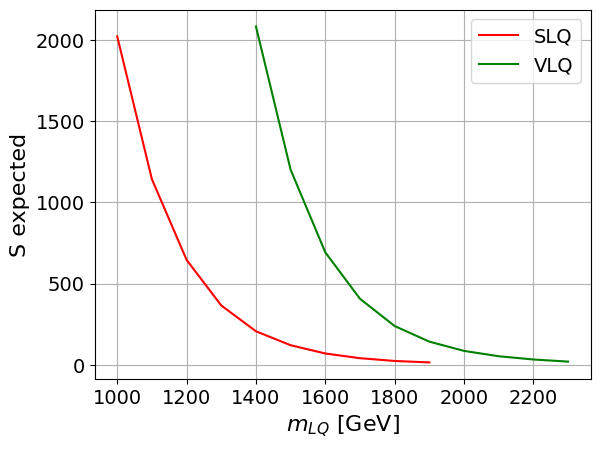

In [17]:
plt.plot(masses_SLQ, S_expected_SLQ, color='red', label='SLQ')
plt.plot(masses_VLQ, S_expected_VLQ, color='green', label='VLQ')
# plt.yscale('log')
plt.xlabel("$m_{LQ}$ [GeV]", fontsize=16)
plt.ylabel("S expected", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid()
plt.legend(fontsize=14)
plt.show()

# 1. DATA FORMAT for CLASSIFIERS

In [18]:
# to save memory
del X_SLQ_all
del X_VLQ_all
del X_B_all

In [19]:
# ---------------------------
# Concatenate all for normalization
# ---------------------------
df_SM = pd.concat(df_B_all.values(), ignore_index=True)
del df_B_all

df_all = pd.concat([df_SM] + list(df_SLQ_all.values()) + list(df_VLQ_all.values()), ignore_index=True)

# ---------------------------
# Normalization
# ---------------------------
scaler = MinMaxScaler()
scaler.fit(df_all)

# Save the scaler
# joblib.dump(scaler, mainfolder + 'saved-models/scaler_features.pkl')

# Apply normalization
df_SM_norm = pd.DataFrame(scaler.transform(df_SM), columns=df_SM.columns)
df_SLQ_norm = {mass: pd.DataFrame(scaler.transform(df_SLQ_all[mass]), columns=df_SLQ_all[mass].columns) for mass in df_SLQ_all}
df_VLQ_norm = {mass: pd.DataFrame(scaler.transform(df_VLQ_all[mass]), columns=df_VLQ_all[mass].columns) for mass in df_VLQ_all}






# ---------------------------
# Divide datasets into train/val/test/pseudo
# ---------------------------
def split_class(df, test_ratio=0.25, val_ratio=0.10, pseudo_ratio=0.25):
    X = df.values
    aux_val_ratio = val_ratio / (1 - test_ratio)
    aux_pseudo_ratio = pseudo_ratio / (1 - test_ratio - val_ratio)

    X_aux, X_test = train_test_split(X, test_size=test_ratio, random_state=42, shuffle=True)
    X_aux2, X_val = train_test_split(X_aux, test_size=aux_val_ratio, random_state=42, shuffle=True)
    X_train, X_pseudo = train_test_split(X_aux2, test_size=aux_pseudo_ratio, random_state=42, shuffle=True)

    return X_train, X_val, X_test, X_pseudo



# ---------------------------
# Divide the datasets
# ---------------------------
split_SM = split_class(df_SM_norm)
split_SLQ = {mass: split_class(df_SLQ_norm[mass]) for mass in df_SLQ_norm}
split_VLQ = {mass: split_class(df_VLQ_norm[mass]) for mass in df_VLQ_norm}



# Example of how to use them
X_train_SM, X_val_SM, X_test_SM, X_pseudo_SM = split_SM
X_train_SLQ1200, X_val_SLQ1200, X_test_SLQ1200, X_pseudo_SLQ1200 = split_SLQ[1200]
X_train_VLQ1600, X_val_VLQ1600, X_test_VLQ1600, X_pseudo_VLQ1600 = split_VLQ[1600]

print('')
print('X_train_SM : ', X_train_SM.shape)
print('X_val_SM : ', X_val_SM.shape)
print('X_test_SM : ', X_test_SM.shape)
print('X_pseudo_SM : ', X_pseudo_SM.shape)

print('')
print('X_train_SLQ1200 : ', X_train_SLQ1200.shape)
print('X_val_SLQ1200 : ', X_val_SLQ1200.shape)
print('X_test_SLQ1200 : ', X_test_SLQ1200.shape)
print('X_pseudo_SLQ1200 : ', X_pseudo_SLQ1200.shape)

print('')
print('X_train_VLQ1600 : ', X_train_VLQ1600.shape)
print('X_val_VLQ1600 : ', X_val_VLQ1600.shape)
print('X_test_VLQ1600 : ', X_test_VLQ1600.shape)
print('X_pseudo_VLQ1600 : ', X_pseudo_VLQ1600.shape)


X_train_SM :  (400000, 53)
X_val_SM :  (100000, 53)
X_test_SM :  (250000, 53)
X_pseudo_SM :  (250000, 53)

X_train_SLQ1200 :  (20000, 53)
X_val_SLQ1200 :  (5000, 53)
X_test_SLQ1200 :  (12500, 53)
X_pseudo_SLQ1200 :  (12500, 53)

X_train_VLQ1600 :  (20000, 53)
X_val_VLQ1600 :  (5000, 53)
X_test_VLQ1600 :  (12500, 53)
X_pseudo_VLQ1600 :  (12500, 53)


In [20]:
# to save memory
del df_SM
del df_SLQ_all
del df_VLQ_all

## SM vs LQ

In [21]:
# --- 1. Combinar todos los LQ en un solo DataFrame ---
df_LQ_list = list(df_SLQ_norm.values()) + list(df_VLQ_norm.values())
df_LQ_norm = pd.concat(df_LQ_list, ignore_index=True)


# --- 2. Igualar número de eventos con SM ---
n_SM = len(df_SM_norm)
n_LQ = len(df_LQ_norm)
n_events = min(n_SM, n_LQ)

print(n_SM, n_LQ, n_events)

df_SM_sample = df_SM_norm.sample(n=n_events, random_state=42)
df_LQ_sample = df_LQ_norm.sample(n=n_events, random_state=42)


# --- 3. Crear X, y ---
X = pd.concat([df_SM_sample, df_LQ_sample], ignore_index=True)
y = np.hstack([np.zeros(n_events), np.ones(n_events)])  # 0=SM, 1=LQ


def split_class(X, Y, test_ratio=0.25, val_ratio=0.25):

    aux_val_ratio = val_ratio / (1 - test_ratio)

    X_aux, X_test, Y_aux, Y_test = train_test_split(X, Y, test_size=test_ratio, random_state=42, shuffle=True)
    X_train, X_val, Y_train, Y_val = train_test_split(X_aux, Y_aux, test_size=val_ratio, random_state=42, shuffle=True)

    return X_train, X_val, X_test, Y_train, Y_val, Y_test


# Divide into train, validation and test
X_train, X_val, X_test, y_train, y_val, y_test = split_class(X, y)


print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

1000000 1000000 1000000
(1125000, 53)
(375000, 53)
(500000, 53)


Accuracy: 0.973, ROC-AUC: 0.99660


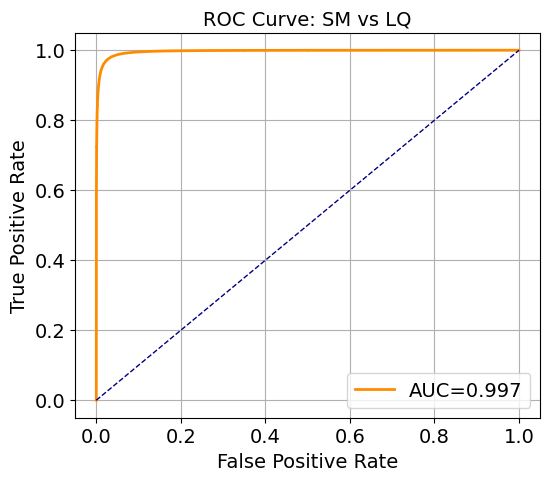

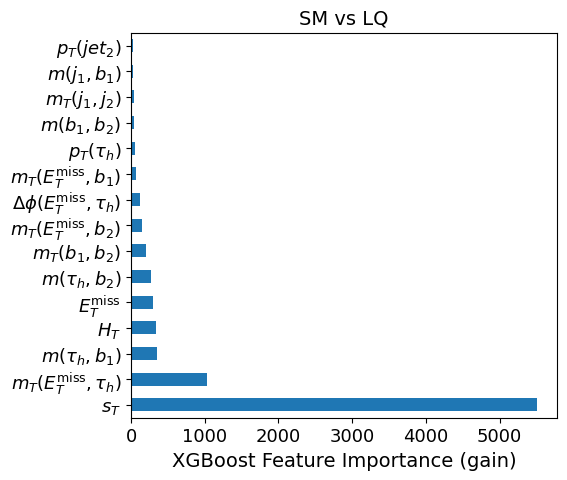

[52, 47, 35, 17, 15, 36, 50, 46, 32, 45, 6, 37, 51, 38, 12]


In [22]:
# LOAD
xgb_clf = XGBClassifier()
xgb_clf.load_model(mainfolder + "saved-models/modelA_SMLQ_14TeV_full.json")


# Evaluate
y_pred = xgb_clf.predict(X_test)
y_pred_proba = xgb_clf.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)
print(f"Accuracy: {acc:.3f}, ROC-AUC: {auc:.5f}")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC={auc:.3f}')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC Curve: SM vs LQ", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
# plt.savefig(mainfolder + "saved-results/ROC_classA.pdf", bbox_inches='tight')
plt.show()


# Feature importance
keys = np.array([r'$p_T(b_1)$',r'$\eta(b_1)$',r'$\phi(b_1)$',
                 r'$p_T(b_2)$',r'$\eta(b_2)$',r'$\phi(b_2)$',
                 r'$p_T(\tau_h)$',r'$\eta(\tau_h)$',r'$\phi(\tau_h)$',
                 r'$p_T(jet_1)$',r'$\eta(jet_1)$',r'$\phi(jet_1)$',
                 r'$p_T(jet_2)$',r'$\eta(jet_2)$',r'$\phi(jet_2)$',
                 r'$E_T^{\mathrm{miss}}$',r'$\phi(E_T^{\mathrm{miss}})$',
                 r'$H_T$',r'$N_{\mathrm{jets}}$',r'$N_{b-\mathrm{jets}}$',
                 r'$\Delta R(\tau_h, b_1)$',r'$\Delta R(\tau_h, b_2)$',r'$\Delta R(b_1, b_2)$',
                 r'$\Delta R(j_1, b_1)$',r'$\Delta R(j_1, b_2)$',r'$\Delta R(j_1, \tau_h)$',
                 r'$\Delta R(j_2, b_1)$',r'$\Delta R(j_2, b_2)$',r'$\Delta R(j_2, \tau_h)$',
                 r'$\Delta R(j_1, j_2)$',
#                  r'$\Delta \phi(\tau_h, b_1)$',r'$\Delta \phi(\tau_h, b_2)$',r'$\Delta \phi(b_1, b_2)$',
                 r'$\Delta \phi(E_T^{\mathrm{miss}}, b_1)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, b_2)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, \tau_h)$',
                 r'$\Delta \phi(E_T^{\mathrm{miss}}, j_1)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, j_2)$',
                 r'$m(\tau_h, b_1)$',r'$m(\tau_h, b_2)$',r'$m(b_1, b_2)$',
                 r'$m(j_1, b_1)$',r'$m(j_1, b_2)$',r'$m(j_1, \tau_h)$',
                 r'$m(j_2, b_1)$',r'$m(j_2, b_2)$',r'$m(j_2, \tau_h)$',
                 r'$m(j_1, j_2)$',
                 r'$m_T(E_T^{\mathrm{miss}}, b_1)$',r'$m_T(E_T^{\mathrm{miss}}, b_2)$',r'$m_T(E_T^{\mathrm{miss}}, \tau_h)$',
                 r'$m_T(E_T^{\mathrm{miss}}, j_1)$',r'$m_T(E_T^{\mathrm{miss}}, j_2)$',
                 r'$m_T(b_1, b_2)$',r'$m_T(j_1, j_2)$',r'$s_T$'])

feature_important = xgb_clf.get_booster().get_score(importance_type='gain')
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(15, columns="score").plot(kind='barh',figsize=(5.5,5)) ## plot top 15 features
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel("XGBoost Feature Importance (gain)", fontsize=14)
plt.legend( fontsize=14).remove()
plt.title(r'SM vs LQ', fontsize=14)
# plt.savefig(mainfolder + "saved-results/XG_feature_importance_classA.pdf", bbox_inches='tight')
plt.show()


# SELECT THE TOP INDICES
num_feats = 15

keys_list = list(keys)  # convert to list
top_names = data.nlargest(num_feats, columns="score").index.tolist()
feat_indices_LQSM = [keys_list.index(name) for name in top_names]

print(feat_indices_LQSM)

## Compute S_pred for pseudo-experiments

In [23]:
# output of all the background events
scores_B = xgb_clf.predict_proba( df_SM_norm )[:, 1]

# output of all the signal events (for the pdf of the general LQ case)
scores_S = xgb_clf.predict_proba( df_LQ_norm )[:, 1]

In [24]:
# output of all the signal events per class (to build the pseudo-experiments)
scores_S_SLQ = {mass: xgb_clf.predict_proba(df_SLQ_norm[mass])[:, 1] for mass in df_SLQ_norm}
scores_S_VLQ = {mass: xgb_clf.predict_proba(df_VLQ_norm[mass])[:, 1] for mass in df_VLQ_norm}

In [25]:
def Z_asimov(S, B):
    if S <= 0 or B <= 0:
        return 0
    return np.sqrt(2 * ((S+B) * np.log(1 + S/B) - S))

###### binned likelihood fit

In [26]:
bins = np.linspace(0, 1, 30)

# normalized histograms of pure signal and pure background
hist_B, _ = np.histogram(scores_B, bins=bins, density=True)
hist_S, _ = np.histogram(scores_S, bins=bins, density=True)


bin_width = bins[1] - bins[0]

pS = hist_S * bin_width
pB = hist_B * bin_width

In [27]:
# FOR SLQ #

S_expected = S_expected_SLQ


n_pseudo = 1000


# to save
S_mean_fit_N = {}
S_std_fit_N  = {}
Z_fit_N = {}



for ii_S, S_it in enumerate(S_expected):
    print('\n----------------')
    print('S_expected = ', S_it)

    S_mean_fit_N[S_it] = []
    S_std_fit_N[S_it]  = []
    Z_fit_N[S_it] = []


    muS_fits = []
    muB_fits = []

    for n_it in range(n_pseudo):

        # 1) pseudo experiment
        N_B = np.random.poisson(B_expected)
        N_S = np.random.poisson(S_it)

        sample_B = np.random.choice(scores_B, N_B, replace=True)
        sample_S = np.random.choice(scores_S_SLQ[masses_SLQ[ii_S]], N_S, replace=True)

        data_scores = np.concatenate([sample_B, sample_S])

        hist_data, _ = np.histogram(data_scores, bins=bins)

        # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
        def neg_logL(params):
            mu_S, mu_B = params

            lambda_i = mu_S * pS + mu_B * pB
            lambda_i = np.clip(lambda_i, 1e-10, None)

            return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

        # 3) Minimizar
        result = minimize(
            neg_logL,
            x0=[S_it, B_expected],
            bounds=[(0, None), (0, None)]
        )

        muS_fit, muB_fit = result.x

        muS_fits.append(muS_fit)
        muB_fits.append(muB_fit)


    mean_muB = np.mean(muB_fits)

    mean_muS = np.mean(muS_fits)
    std_muS  = np.std(muS_fits)

    S_mean_fit_N[S_it].append(mean_muS)
    S_std_fit_N[S_it].append(std_muS)


    # significance
    logL_hat = -neg_logL([mean_muS, mean_muB])
    logL_null = -neg_logL([0, mean_muB])

    q0 = -2 * (logL_null - logL_hat)

    Z = np.sqrt(q0)

    Z_fit_N[S_it].append(Z)

    print("S =", mean_muS, "+-", std_muS)
    print("Z =", Z)
    print('')



----------------
S_expected =  2023
S = 1610.5084729005869 +- 47.28318921871945
Z = 72.46383475015715


----------------
S_expected =  1143
S = 992.2939253729818 +- 36.13182852856892
Z = 49.47231145491936


----------------
S_expected =  646
S = 599.4963711891924 +- 31.168384706731096
Z = 32.75082689955504


----------------
S_expected =  365
S = 353.3352299551494 +- 22.281448798827636
Z = 22.291405346646606


----------------
S_expected =  206
S = 206.50408941129533 +- 18.359828887645552
Z = 14.425911599172707


----------------
S_expected =  120
S = 124.7254895497015 +- 16.81296234333645
Z = 10.628238281437454


----------------
S_expected =  69
S = 72.35753982289788 +- 14.472809073767282
Z = 5.676022399721642


----------------
S_expected =  40
S = 42.96887154020145 +- 14.18257163432967
Z = 4.58141602934957


----------------
S_expected =  23
S = 25.53471137286137 +- 12.423448603007351
Z = 1.7989292050364205


----------------
S_expected =  14
S = 15.601860190304633 +- 10.658015695

In [28]:
# FOR VLQ #

S_expected = S_expected_SLQ # same number of events


n_pseudo = 1000


# to save
S_mean_fit_V = {}
S_std_fit_V  = {}
Z_fit_V = {}



for ii_S, S_it in enumerate(S_expected):
    print('\n----------------')
    print('S_expected = ', S_it)

    S_mean_fit_V[S_it] = []
    S_std_fit_V[S_it]  = []
    Z_fit_V[S_it] = []


    muS_fits = []
    muB_fits = []

    for n_it in range(n_pseudo):

        # 1) pseudo experiment
        N_B = np.random.poisson(B_expected)
        N_S = np.random.poisson(S_it)

        sample_B = np.random.choice(scores_B, N_B, replace=True)
        sample_S = np.random.choice(scores_S_VLQ[masses_VLQ[ii_S]], N_S, replace=True)

        data_scores = np.concatenate([sample_B, sample_S])

        hist_data, _ = np.histogram(data_scores, bins=bins)

        # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
        def neg_logL(params):
            mu_S, mu_B = params

            lambda_i = mu_S * pS + mu_B * pB
            lambda_i = np.clip(lambda_i, 1e-10, None)

            return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

        # 3) Minimizar
        result = minimize(
            neg_logL,
            x0=[S_it, B_expected],
            bounds=[(0, None), (0, None)]
        )

        muS_fit, muB_fit = result.x

        muS_fits.append(muS_fit)
        muB_fits.append(muB_fit)


    mean_muB = np.mean(muB_fits)

    mean_muS = np.mean(muS_fits)
    std_muS  = np.std(muS_fits)

    S_mean_fit_V[S_it].append(mean_muS)
    S_std_fit_V[S_it].append(std_muS)


    # significance
    logL_hat = -neg_logL([mean_muS, mean_muB])
    logL_null = -neg_logL([0, mean_muB])

    q0 = -2 * (logL_null - logL_hat)

    Z = np.sqrt(q0)

    Z_fit_V[S_it].append(Z)

    print("S =", mean_muS, "+-", std_muS)
    print("Z =", Z)
    print('')



----------------
S_expected =  2023
S = 1967.874487652697 +- 60.52891362249291
Z = 83.10959869439208


----------------
S_expected =  1143
S = 1123.9468715397209 +- 36.304924921632114
Z = 56.7061870702685


----------------
S_expected =  646
S = 645.4534162395827 +- 26.730488283167094
Z = 35.91032709528555


----------------
S_expected =  365
S = 369.936811386527 +- 22.235078189980815
Z = 23.044834549533963


----------------
S_expected =  206
S = 210.6419487651147 +- 18.649046765378532
Z = 15.543130616059651


----------------
S_expected =  120
S = 124.68146694711096 +- 16.33667094299642
Z = 8.763412577462814


----------------
S_expected =  69


/tmp/ipykernel_1149/2772170123.py:78: RuntimeWarning: invalid value encountered in sqrt
  Z = np.sqrt(q0)


S = 71.53655326312654 +- 14.46029130326714
Z = nan


----------------
S_expected =  40
S = 42.01699637793933 +- 13.343361970181927
Z = 1.8209942724853285


----------------
S_expected =  23
S = 24.4097534370075 +- 12.186498732483763
Z = 1.8939695706077246


----------------
S_expected =  14
S = 15.12640598056016 +- 10.755066993904736
Z = 1.4136602861427987



In [29]:
# mean between scalar and vector
S_mean_fit_both = []
S_std_fit_both = []

for i in S_mean_fit_N:

    S_mean_fit_both.append( np.mean([S_mean_fit_N[i][0], S_mean_fit_V[i][0]]) )
    S_std_fit_both.append( np.mean([S_std_fit_N[i][0], S_std_fit_V[i][0]]) )

# SLQ vs VLQ (include Poisson S_expected)

In [30]:
X_train_list, y_train_list, S_poiss_train_list = [], [], []
X_val_list,   y_val_list,   S_poiss_val_list   = [], [], []
X_test_list,  y_test_list,  S_poiss_test_list  = [], [], []

for iit, m_s in enumerate(masses_SLQ):

        # -------- SLQ --------
        X_train_s, X_val_s, X_test_s, _ = split_SLQ[masses_SLQ[iit]]

        X_train_list.append(X_train_s)
        y_train_list.append(np.zeros(len(X_train_s)))
        poisson_samples = np.random.poisson(lam=S_mean_fit_both[iit], size=len(X_train_s))
        S_poiss_train_list.append(poisson_samples)

        X_val_list.append(X_val_s)
        y_val_list.append(np.zeros(len(X_val_s)))
        poisson_samples = np.random.poisson(lam=S_mean_fit_both[iit], size=len(X_val_s))
        S_poiss_val_list.append(poisson_samples)

        X_test_list.append(X_test_s)
        y_test_list.append(np.zeros(len(X_test_s)))
        poisson_samples = np.random.poisson(lam=S_mean_fit_both[iit], size=len(X_test_s))
        S_poiss_test_list.append(poisson_samples)


# for iit, m_v in enumerate(masses_VLQ):

        # -------- VLQ --------
        X_train_v, X_val_v, X_test_v, _ = split_VLQ[masses_VLQ[iit]]

        X_train_list.append(X_train_v)
        y_train_list.append(np.ones(len(X_train_v)))
        poisson_samples = np.random.poisson(lam=S_mean_fit_both[iit], size=len(X_train_v))
        S_poiss_train_list.append(poisson_samples)

        X_val_list.append(X_val_v)
        y_val_list.append(np.ones(len(X_val_v)))
        poisson_samples = np.random.poisson(lam=S_mean_fit_both[iit], size=len(X_val_v))
        S_poiss_val_list.append(poisson_samples)

        X_test_list.append(X_test_v)
        y_test_list.append(np.ones(len(X_test_v)))
        poisson_samples = np.random.poisson(lam=S_mean_fit_both[iit], size=len(X_test_v))
        S_poiss_test_list.append(poisson_samples)


# Concatenate
# TRAIN
X_train_spin = np.vstack(X_train_list)
y_train_spin = np.concatenate(y_train_list)
S_poiss_train = np.concatenate(S_poiss_train_list)

# add S_poiss as extra feature
X_train_spin = np.column_stack([X_train_spin, S_poiss_train])


# VAL
X_val_spin = np.vstack(X_val_list)
y_val_spin = np.concatenate(y_val_list)
S_poiss_val = np.concatenate(S_poiss_val_list)

X_val_spin = np.column_stack([X_val_spin, S_poiss_val])


# TEST
X_test_spin = np.vstack(X_test_list)
y_test_spin = np.concatenate(y_test_list)
S_poiss_test = np.concatenate(S_poiss_test_list)

X_test_spin = np.column_stack([X_test_spin, S_poiss_test])


print(X_train_spin.shape)
print(X_val_spin.shape)
print(X_test_spin.shape)

(400000, 54)
(100000, 54)
(250000, 54)


In [31]:
classifier_spin = XGBClassifier(
    n_estimators=1500,
    learning_rate=0.1,
    max_depth=5,
    reg_lambda=1.0,
    reg_alpha=0.0,
    gamma=0.0,
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42,
    early_stopping_rounds=50
)

classifier_spin.fit(
    X_train_spin, y_train_spin,
    eval_set=[(X_train_spin, y_train_spin),
              (X_val_spin, y_val_spin)],
    verbose=True
)

classifier_spin.save_model(mainfolder + "saved-models/modelB_spin_S_poiss_beta09.json")

[0]	validation_0-logloss:0.68606	validation_1-logloss:0.68614
[1]	validation_0-logloss:0.67996	validation_1-logloss:0.68014
[2]	validation_0-logloss:0.67458	validation_1-logloss:0.67478
[3]	validation_0-logloss:0.67000	validation_1-logloss:0.67027
[4]	validation_0-logloss:0.66587	validation_1-logloss:0.66616
[5]	validation_0-logloss:0.66242	validation_1-logloss:0.66277
[6]	validation_0-logloss:0.65895	validation_1-logloss:0.65937
[7]	validation_0-logloss:0.65611	validation_1-logloss:0.65663
[8]	validation_0-logloss:0.65361	validation_1-logloss:0.65420
[9]	validation_0-logloss:0.65146	validation_1-logloss:0.65209
[10]	validation_0-logloss:0.64925	validation_1-logloss:0.64996
[11]	validation_0-logloss:0.64724	validation_1-logloss:0.64805
[12]	validation_0-logloss:0.64546	validation_1-logloss:0.64632
[13]	validation_0-logloss:0.64364	validation_1-logloss:0.64461
[14]	validation_0-logloss:0.64212	validation_1-logloss:0.64309
[15]	validation_0-logloss:0.64070	validation_1-logloss:0.64169
[1

Global AUC = 0.74478508624


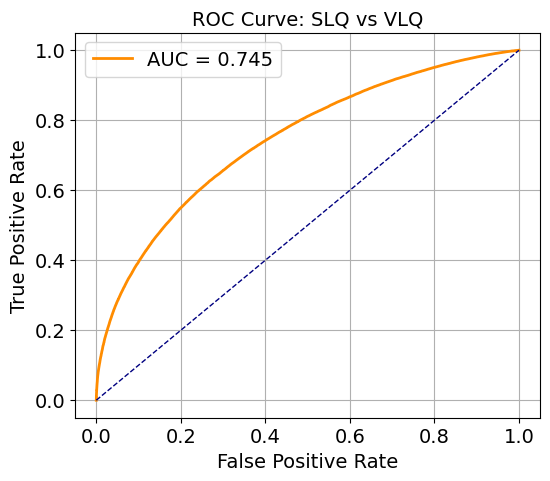

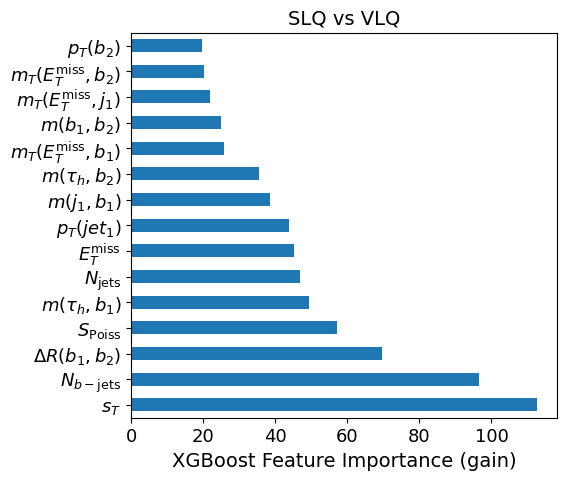

[52, 19, 22, 53, 35, 18, 15, 9, 38, 36, 45, 37, 48, 46, 3]


In [32]:
# LOAD
classifier_spin = XGBClassifier()
classifier_spin.load_model(mainfolder + "saved-models/modelB_spin_S_poiss_beta09.json")


y_score = classifier_spin.predict_proba(X_test_spin)[:, 1]


fpr, tpr, thresholds = roc_curve(y_test_spin, y_score)
roc_auc = roc_auc_score(y_test_spin, y_score)

print("Global AUC =", roc_auc)


plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC Curve: SLQ vs VLQ", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
# plt.savefig(mainfolder + 'saved-results/ROC_classB.pdf', bbox_inches='tight')
plt.show()




keys = np.array([r'$p_T(b_1)$',r'$\eta(b_1)$',r'$\phi(b_1)$',
                 r'$p_T(b_2)$',r'$\eta(b_2)$',r'$\phi(b_2)$',
                 r'$p_T(\tau_h)$',r'$\eta(\tau_h)$',r'$\phi(\tau_h)$',
                 r'$p_T(jet_1)$',r'$\eta(jet_1)$',r'$\phi(jet_1)$',
                 r'$p_T(jet_2)$',r'$\eta(jet_2)$',r'$\phi(jet_2)$',
                 r'$E_T^{\mathrm{miss}}$',r'$\phi(E_T^{\mathrm{miss}})$',
                 r'$H_T$',r'$N_{\mathrm{jets}}$',r'$N_{b-\mathrm{jets}}$',
                 r'$\Delta R(\tau_h, b_1)$',r'$\Delta R(\tau_h, b_2)$',r'$\Delta R(b_1, b_2)$',
                 r'$\Delta R(j_1, b_1)$',r'$\Delta R(j_1, b_2)$',r'$\Delta R(j_1, \tau_h)$',
                 r'$\Delta R(j_2, b_1)$',r'$\Delta R(j_2, b_2)$',r'$\Delta R(j_2, \tau_h)$',
                 r'$\Delta R(j_1, j_2)$',
#                  r'$\Delta \phi(\tau_h, b_1)$',r'$\Delta \phi(\tau_h, b_2)$',r'$\Delta \phi(b_1, b_2)$',
                 r'$\Delta \phi(E_T^{\mathrm{miss}}, b_1)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, b_2)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, \tau_h)$',
                 r'$\Delta \phi(E_T^{\mathrm{miss}}, j_1)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, j_2)$',
                 r'$m(\tau_h, b_1)$',r'$m(\tau_h, b_2)$',r'$m(b_1, b_2)$',
                 r'$m(j_1, b_1)$',r'$m(j_1, b_2)$',r'$m(j_1, \tau_h)$',
                 r'$m(j_2, b_1)$',r'$m(j_2, b_2)$',r'$m(j_2, \tau_h)$',
                 r'$m(j_1, j_2)$',
                 r'$m_T(E_T^{\mathrm{miss}}, b_1)$',r'$m_T(E_T^{\mathrm{miss}}, b_2)$',r'$m_T(E_T^{\mathrm{miss}}, \tau_h)$',
                 r'$m_T(E_T^{\mathrm{miss}}, j_1)$',r'$m_T(E_T^{\mathrm{miss}}, j_2)$',
                 r'$m_T(b_1, b_2)$',r'$m_T(j_1, j_2)$',r'$s_T$',
                #  r'$m_{\mathrm{LQ}}^{\mathrm{reg}}$',
                 r'$S_{\mathrm{Poiss}}$'])

feature_important = classifier_spin.get_booster().get_score(importance_type='gain')
values = list(feature_important.values())


data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(15, columns="score").plot(kind='barh',figsize=(5.5,5)) ## plot top 15 features
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel("XGBoost Feature Importance (gain)", fontsize=14)
plt.legend( fontsize=12).remove()
plt.title(r'SLQ vs VLQ', fontsize=14)
# plt.savefig(mainfolder + 'saved-results/XG_feature_importance_classB.pdf', bbox_inches='tight')
plt.show()


# SELECT THE TOP INDICES
num_feats = 15

keys_list = list(keys)  # convert to list
top_names = data.nlargest(num_feats, columns="score").index.tolist()
feat_indices_LQSM = [keys_list.index(name) for name in top_names]

print(feat_indices_LQSM)

$m_{LQ_3^S}=$1200 GeV,   AUC = 0.77289
$m_{LQ_3^S}=$1500 GeV,   AUC = 0.72897
$m_{LQ_3^S}=$1800 GeV,   AUC = 0.69927


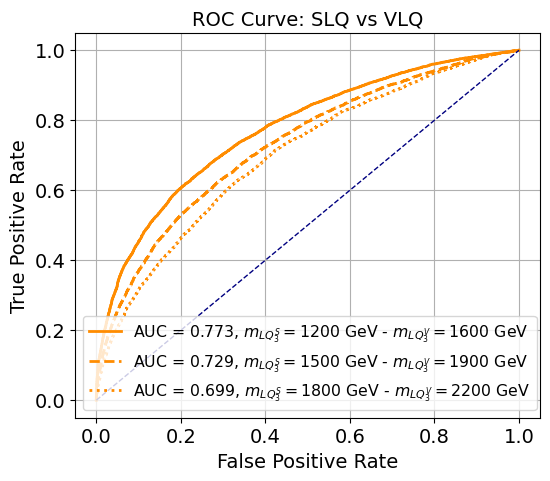

In [33]:
S_column = X_test_spin[:, -1]

# mSLQ_plot = [1200, 1500, 1800]
# mVLQ_plot = [1600, 1900, 2200]

linestyles = ['-','-','-', '--','--','--', ':', ':', ':']
# colors_SLQ = ['lightcoral', 'red', 'firebrick']
# colors_VLQ = ['limegreen', 'green', 'darkgreen']

plt.figure(figsize=(6,5))

# evaluate per sector
for iit, S_id in enumerate(S_expected_SLQ):
    # if iit == 0 or iit == 1 or iit == 9:
    #     continue
    # else:
    if iit == 2 or iit == 5 or iit == 8:

        mask = (S_column < S_id * 1.1) & (0.9 * S_id < S_column)

        y_true_Spoiss = y_test_spin[mask]
        y_score_Spoiss = y_score[mask]

        fpr, tpr, _ = roc_curve(y_true_Spoiss, y_score_Spoiss)
        auc_sector = roc_auc_score(y_true_Spoiss, y_score_Spoiss)

        print(f"$m_{{LQ_3^S}}=${masses_SLQ[iit]} GeV,   AUC = {auc_sector:.5f}")


        plt.plot(fpr, tpr, color='darkorange', linestyle=linestyles[iit], lw=2, label=f"AUC = {auc_sector:.3f}, $m_{{LQ_3^S}}=${masses_SLQ[iit]} GeV - $m_{{LQ_3^V}}=${masses_VLQ[iit]} GeV")



plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC Curve: SLQ vs VLQ", fontsize=14)
plt.grid(True)
plt.legend(fontsize=11.3)
# plt.savefig(mainfolder + 'saved-results/ROC_classB_multi.pdf', bbox_inches='tight')
plt.show()

# JOIN BOTH ML

In [34]:
# --- Clasificador A: SM vs LQ ---

scoresA_SM = xgb_clf.predict_proba( df_SM_norm )[:,1]

scoresA_SLQ = {}
scoresA_VLQ = {}

m_SLQ = [1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]
m_VLQ = [1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]

S_exp_SLQ = S_expected_SLQ[2:]
S_exp_both = S_mean_fit_both[2:]

for m in m_SLQ:
    scoresA_SLQ[m] = xgb_clf.predict_proba( df_SLQ_norm[m] )[:,1]

for m in m_VLQ:
    scoresA_VLQ[m] = xgb_clf.predict_proba( df_VLQ_norm[m] )[:,1]

In [35]:
# --- Clasificador B: SLQ vs VLQ ---

X_sm = df_SM_norm

rand_samples_B =np.random.randint(1, S_exp_both[0] + S_std_fit_both[0], size=len(X_sm))

X_sm = np.column_stack([X_sm, rand_samples_B])

scoresB_SM = classifier_spin.predict_proba(X_sm)[:,1]


scoresB_SLQ = {}
scoresB_VLQ = {}

for iit, S_id in enumerate(m_SLQ):

    X_s = df_SLQ_norm[m_SLQ[iit]].values
    X_v = df_VLQ_norm[m_VLQ[iit]].values

    poisson_samples_SLQ = np.random.poisson(lam=S_exp_both[iit], size=len(X_s))
    poisson_samples_VLQ = np.random.poisson(lam=S_exp_both[iit], size=len(X_v))

    X_s = np.column_stack([X_s, poisson_samples_SLQ])
    X_v = np.column_stack([X_v, poisson_samples_VLQ])

    scoresB_SLQ[m_SLQ[iit]] = classifier_spin.predict_proba(X_s)[:,1]
    scoresB_VLQ[m_VLQ[iit]] = classifier_spin.predict_proba(X_v)[:,1]

In [36]:
# --- Juntar los scores del clasificador A y B

events_SM = np.column_stack([scoresA_SM, scoresB_SM])

events_SLQ = {}
for m in scoresA_SLQ:
    events_SLQ[m] = np.column_stack([scoresA_SLQ[m], scoresB_SLQ[m]])

events_VLQ = {}
for m in scoresA_VLQ:
    events_VLQ[m] = np.column_stack([scoresA_VLQ[m], scoresB_VLQ[m]])

#### Define the test statistic

In [37]:
def compute_test_statistic(scoresA, scoresB, threshold):
    """
    Sum of Log-Likelihood Ratios (LLR)

    T = Sum log (P(VLQ) / P(SLQ))

    P(VLQ) = score SLQ vs VLQ classifier
    P(SLQ) = 1 - score SLQ vs VLQ classifier
    """

    mask = scoresA > threshold

    scoresB_sel = scoresB[mask]

    if len(scoresB_sel) == 0:
        return 0

    eps = 1e-6
    s = np.clip(scoresB_sel, eps, 1-eps)

    T = np.sum(np.log(s/(1-s)))

    return T

### For all the masses

In [38]:
# funcion para generar pseudo experimentos (da los scores de ambos clasificadores para ese pseudo)

def generate_pseudo(events_B, events_S, N_B, N_S):

    sample_B = events_B[np.random.randint(len(events_B), size=N_B)]
    sample_S = events_S[np.random.randint(len(events_S), size=N_S)]

    sample_all = np.vstack([sample_B, sample_S])

    scoresA = sample_all[:,0]
    scoresB = sample_all[:,1]

    return scoresA, scoresB

In [39]:
B_expected = 45962

S_exp_SLQ = [round(fid_xsec_SLQ_14TeV(mmm, beta) * Lum) for mmm in m_SLQ]
S_exp_VLQ = [round(fid_xsec_VLQ_14TeV(mmm, beta) * Lum) for mmm in m_VLQ]

print('beta = ', beta)
print('\nB_expected: ', B_expected)
print('\nS_exp_SLQ: ', S_exp_SLQ, '   m =', m_SLQ)
print('S_exp_VLQ: ', S_exp_VLQ, '   m =', m_VLQ)
print('S_exp_both: ', S_exp_both)

beta =  0.9

B_expected:  45962

S_exp_SLQ:  [646, 365, 206, 120, 69, 40, 23, 14]    m = [1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]
S_exp_VLQ:  [692, 406, 238, 142, 85, 52, 32, 19]    m = [1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]
S_exp_both:  [np.float64(622.4748937143875), np.float64(361.6360206708382), np.float64(208.573019088205), np.float64(124.70347824840624), np.float64(71.9470465430122), np.float64(42.492933959070385), np.float64(24.972232404934434), np.float64(15.364133085432396)]


#### Distribution of the statistic with only SLQ and only VLQ

In [40]:
n_pseudo_TRUE = 1000
threshold_A = 0.95

In [41]:
mu_S = []
mu_V = []

sigma_S = []
sigma_V = []

for S_it in range(len(S_exp_SLQ)):

    print("\n==========================")
    print("S_expected SLQ =", S_exp_SLQ[S_it])
    # print("S_expected VLQ =", S_exp_VLQ[S_it]) # same number of events

    # dado un S, le asigna la masa (del SLQ o VLQ) correspondiente
    mass_SLQ = m_SLQ[S_it]
    mass_VLQ = m_VLQ[S_it]
    print("mass_SLQ =", mass_SLQ, " GeV")
    print("mass_VLQ =", mass_VLQ, " GeV")


    # computamos el T statistic para todos los pseudo
    T_SLQ = []
    T_VLQ = []

    for i in range(n_pseudo_TRUE):

        N_B = np.random.poisson(B_expected)
        N_S = np.random.poisson(S_exp_SLQ[S_it])

        scoresA, scoresB = generate_pseudo( events_SM, events_SLQ[mass_SLQ], N_B, N_S )

        T = compute_test_statistic(scoresA, scoresB, threshold_A)

        T_SLQ.append(T)


        N_S = np.random.poisson(S_exp_SLQ[S_it]) # same number of events

        scoresA, scoresB = generate_pseudo( events_SM, events_VLQ[mass_VLQ], N_B, N_S )

        T = compute_test_statistic(scoresA, scoresB, threshold_A)

        T_VLQ.append(T)

        # Compute the Z of the distributions
    mu_S.append( np.mean(T_SLQ) )
    mu_V.append( np.mean(T_VLQ) )

    sigma_S.append( np.std(T_SLQ) )
    sigma_V.append( np.std(T_VLQ) )

print(mu_S)
print(mu_V)

print(sigma_S)
print(sigma_V)


S_expected SLQ = 646
mass_SLQ = 1200  GeV
mass_VLQ = 1600  GeV

S_expected SLQ = 365
mass_SLQ = 1300  GeV
mass_VLQ = 1700  GeV

S_expected SLQ = 206
mass_SLQ = 1400  GeV
mass_VLQ = 1800  GeV

S_expected SLQ = 120
mass_SLQ = 1500  GeV
mass_VLQ = 1900  GeV

S_expected SLQ = 69
mass_SLQ = 1600  GeV
mass_VLQ = 2000  GeV

S_expected SLQ = 40
mass_SLQ = 1700  GeV
mass_VLQ = 2100  GeV

S_expected SLQ = 23
mass_SLQ = 1800  GeV
mass_VLQ = 2200  GeV

S_expected SLQ = 14
mass_SLQ = 1900  GeV
mass_VLQ = 2300  GeV
[np.float32(-272.39008), np.float32(-162.30376), np.float32(-96.719536), np.float32(-64.678185), np.float32(-45.544235), np.float32(-35.4265), np.float32(-29.781868), np.float32(-26.264744)]
[np.float32(409.5915), np.float32(190.16032), np.float32(80.953575), np.float32(30.708164), np.float32(4.0378437), np.float32(-9.393022), np.float32(-15.918205), np.float32(-17.656609)]
[np.float32(24.96183), np.float32(19.19741), np.float32(15.512024), np.float32(13.648552), np.float32(12.146753), n

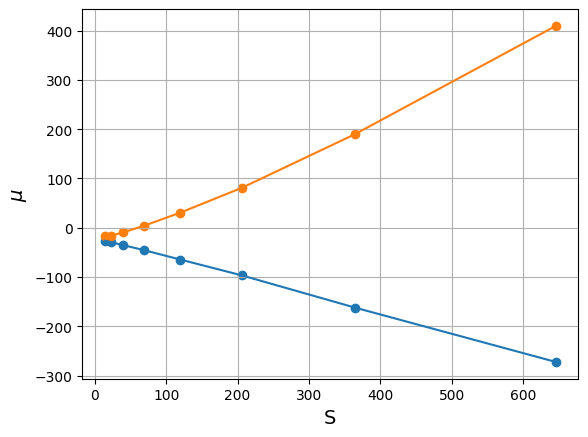

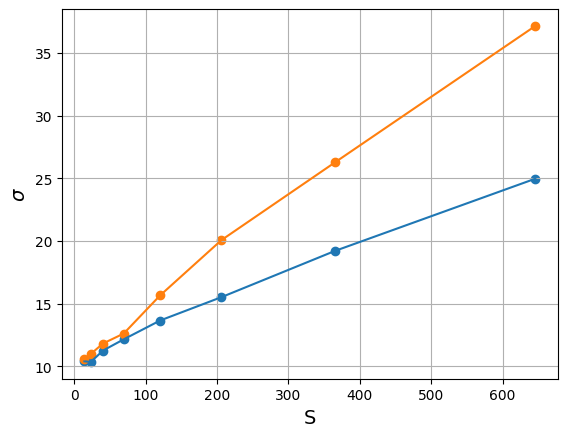

In [42]:
f_mu_S = interp1d(S_exp_SLQ, mu_S, kind='linear', fill_value="extrapolate")
f_mu_V = interp1d(S_exp_SLQ, mu_V, kind='linear', fill_value="extrapolate")

f_sigma_S = interp1d(S_exp_SLQ, sigma_S, kind='linear', fill_value="extrapolate")
f_sigma_V = interp1d(S_exp_SLQ, sigma_V, kind='linear', fill_value="extrapolate")



S_plot = np.linspace(min(S_exp_SLQ), max(S_exp_SLQ), 100)



plt.scatter(S_exp_SLQ, mu_S, marker='o')
plt.plot(S_plot, f_mu_S(S_plot))
plt.scatter(S_exp_SLQ, mu_V, marker='o')
plt.plot(S_plot, f_mu_V(S_plot))

plt.xlabel("S", fontsize=14)
plt.ylabel(r"$\mu$", fontsize=14)

plt.grid()
plt.show()


plt.scatter(S_exp_SLQ, sigma_S, marker='o')
plt.plot(S_plot, f_sigma_S(S_plot))
plt.scatter(S_exp_SLQ, sigma_V, marker='o')
plt.plot(S_plot, f_sigma_V(S_plot))

plt.xlabel("S", fontsize=14)
plt.ylabel(r"$\sigma$", fontsize=14)

plt.grid()
plt.show()

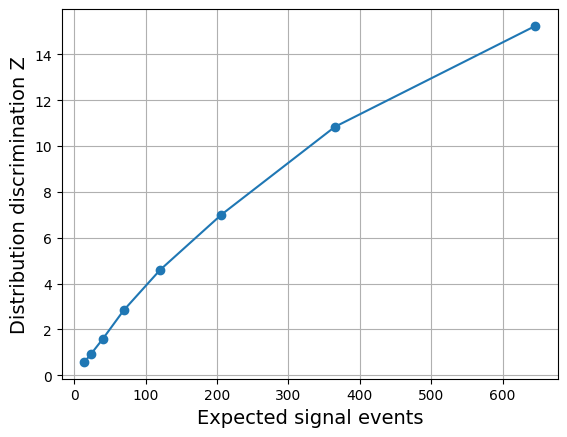

 Z:        5
 S:        134.48213308348923
 m_SLQ:    1483.1603103680359  [GeV]
 m_VLQ:    1883.1603103680359  [GeV]



/tmp/ipykernel_1149/699503059.py:28: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  mSLQ_threshold = fsolve(lambda x: f_results_Z_mSLQ(x) - Z_threshold,1500)[0]
/tmp/ipykernel_1149/699503059.py:29: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  mVLQ_threshold = fsolve(lambda x: f_results_Z_mVLQ(x) - Z_threshold,1900)[0]


In [43]:
Z_threshold = 5

results_Z_gauss = []

for pair_it in range(len(mu_S)):
    Z = abs(mu_V[pair_it] - mu_S[pair_it]) / np.sqrt(sigma_S[pair_it]**2 + sigma_V[pair_it]**2)

    results_Z_gauss.append(Z)


plt.plot(S_exp_SLQ, results_Z_gauss, marker='o')

plt.xlabel("Expected signal events", fontsize=14)
plt.ylabel("Distribution discrimination Z", fontsize=14)

plt.grid()
plt.show()


#  interpolate
f_results_Z = interp1d(S_exp_SLQ, results_Z_gauss, kind='linear', fill_value="extrapolate")
f_results_Z_mSLQ = interp1d(m_SLQ, results_Z_gauss, kind='linear', fill_value="extrapolate")
f_results_Z_mVLQ = interp1d(m_VLQ, results_Z_gauss, kind='linear', fill_value="extrapolate")


# find the S or the mass such that we get Z_threshold
S_threshold = fsolve(lambda x: f_results_Z(x) - Z_threshold,150)[0]
mSLQ_threshold = fsolve(lambda x: f_results_Z_mSLQ(x) - Z_threshold,1500)[0]
mVLQ_threshold = fsolve(lambda x: f_results_Z_mVLQ(x) - Z_threshold,1900)[0]

print(' Z:       ', Z_threshold)
print(' S:       ', S_threshold)
print(' m_SLQ:   ', mSLQ_threshold, ' [GeV]')
print(' m_VLQ:   ', mVLQ_threshold, ' [GeV]\n')

#### Prepare the data

##### To compute S_expected for each pseudo using the 1st classifier we need the PDFs

In [44]:
# --- Clasificador A: SM vs LQ ---

# output of all the signal events
scoresA_S = xgb_clf.predict_proba( df_LQ_norm )[:, 1]



bins = np.linspace(0, 1, 30)

# normalized histograms of pure signal and pure background
hist_B, _ = np.histogram(scoresA_SM, bins=bins, density=True)
hist_S, _ = np.histogram(scoresA_S, bins=bins, density=True)


bin_width = bins[1] - bins[0]

pS = hist_S * bin_width
pB = hist_B * bin_width

##### to compute the closest mass/index/bechmark

In [45]:
def search_bench(S_pseudo, S_list_means, S_list_std, masses_list=None):
    """ finds the index of the closest benchmark

    Inputs:
    -----------
    S_pseudo : float -> S computed or fitted (e.g. muS_fits_SLQ[i]).
    S_list_means : list/array -> S_mean_fit_both_NEW.
    S_list_std : list/array -> S_std_fit_both_NEW.
    masses_list : list/array (optional) -> masses_NEW.

    Outputs:
    --------
    if masses_list es None -> returns only the index
    if masses_list se incluye -> returns (index, closest mass).
    """
    # convert to array
    means = np.array(S_list_means)
    stds = np.array(S_list_std)

    # do not divide by 0
    stds = np.where(stds == 0, 1e-10, stds)

    # compute the distance to the means, weighted by the std
    z_scores = np.abs(S_pseudo - means) / stds

    # seach the closest index
    idx_min = np.argmin(z_scores)

    # if you also want the mass
    if masses_list is not None:
        best_mass = masses_list[idx_min]
        return idx_min, best_mass

    return idx_min

### Super loop


S_expected_SLQ = 646
mass_SLQ = 1200  GeV
mass_VLQ = 1600  GeV


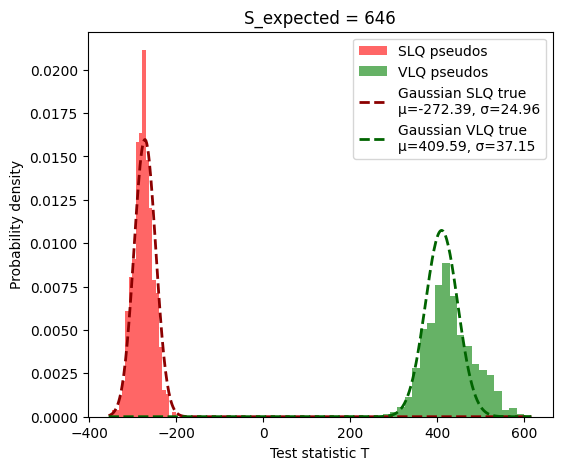

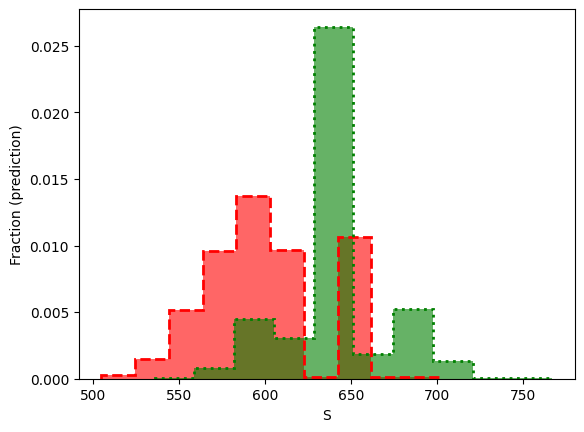

S mean SLQ:  598.8848413017655
S std SLQ:  31.690916732295996
S mean VLQ:  645.054115780733
S std VLQ:  28.20513670750034


------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.938
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.062

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.73
2 = both     : 0.0
3 = neither  : 0.27

------
 COMPARING WITH CONTINUOUS MASSES (interpolation) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.858
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.142

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.889
2 = both     : 0.0
3 = neither  : 0.111

------
 COMPARING WITH THE PREVIOUSLY KNOWN PDF 
TESTING SLQ
Classification fractio

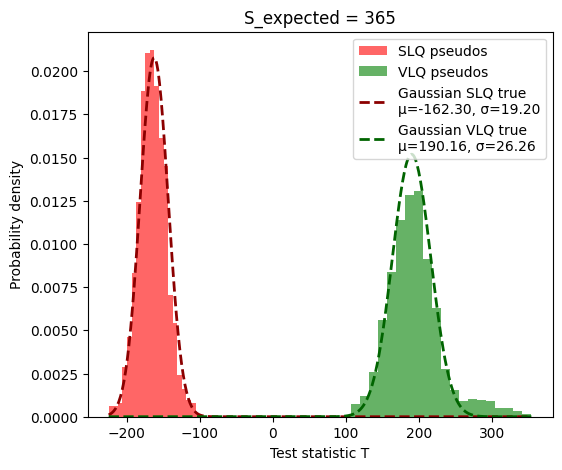

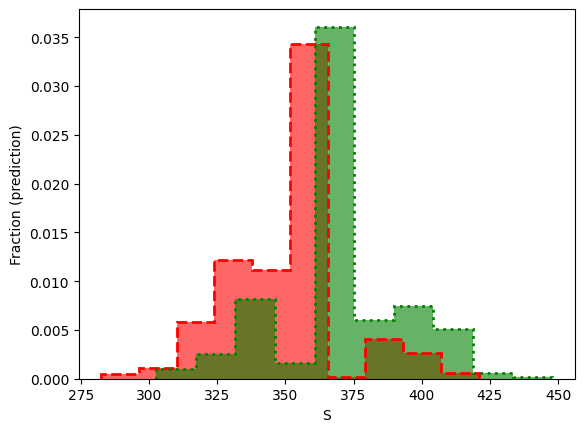

S mean SLQ:  353.7452441641262
S std SLQ:  22.134429967170252
S mean VLQ:  368.6372307850127
S std VLQ:  22.64933066595083


------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.949
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.051

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.874
2 = both     : 0.0
3 = neither  : 0.126

------
 COMPARING WITH CONTINUOUS MASSES (interpolation) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.93
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.07

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.936
2 = both     : 0.0
3 = neither  : 0.064

------
 COMPARING WITH THE PREVIOUSLY KNOWN PDF 
TESTING SLQ
Classification fracti

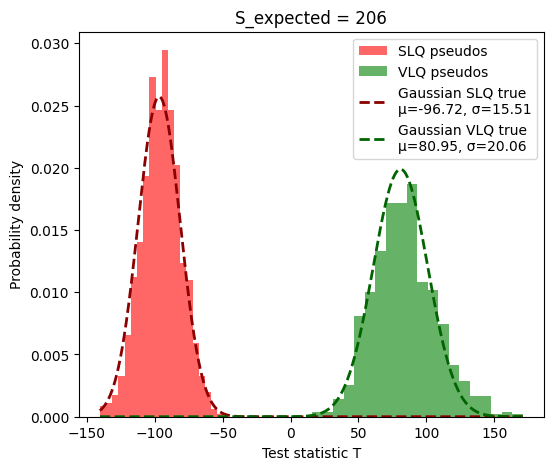

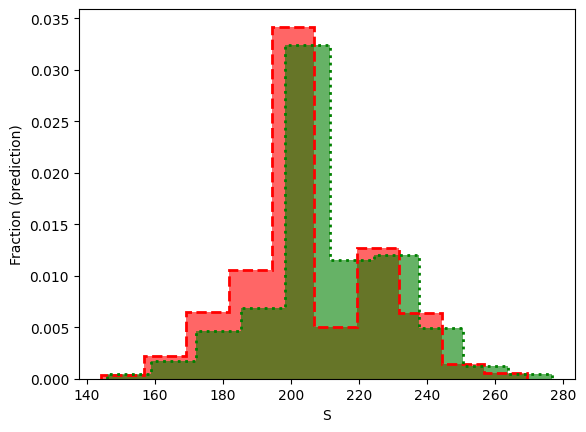

S mean SLQ:  207.2349379643008
S std SLQ:  19.49263083817048
S mean VLQ:  211.29073131797912
S std VLQ:  19.243745330176868


------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.959
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.041

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.91
2 = both     : 0.0
3 = neither  : 0.09

------
 COMPARING WITH CONTINUOUS MASSES (interpolation) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.954
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.046

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.962
2 = both     : 0.0
3 = neither  : 0.038

------
 COMPARING WITH THE PREVIOUSLY KNOWN PDF 
TESTING SLQ
Classification fract

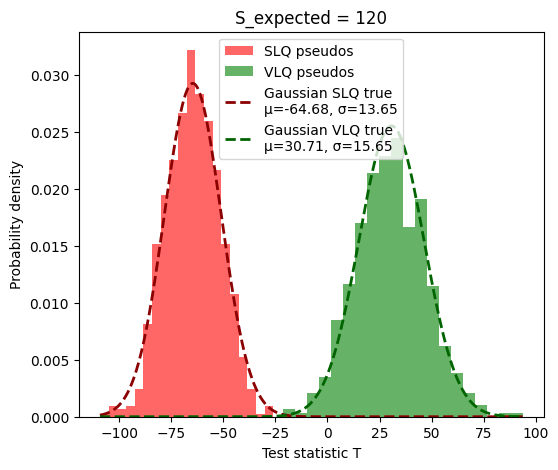

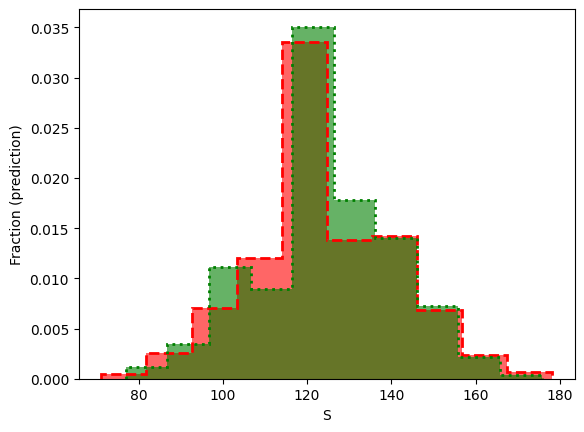

S mean SLQ:  124.19877419552365
S std SLQ:  16.990263830528896
S mean VLQ:  123.78191423133909
S std VLQ:  16.25620424196601


------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.956
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.044

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.946
2 = both     : 0.0
3 = neither  : 0.054

------
 COMPARING WITH CONTINUOUS MASSES (interpolation) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.959
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.041

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.95
2 = both     : 0.0
3 = neither  : 0.05

------
 COMPARING WITH THE PREVIOUSLY KNOWN PDF 
TESTING SLQ
Classification frac

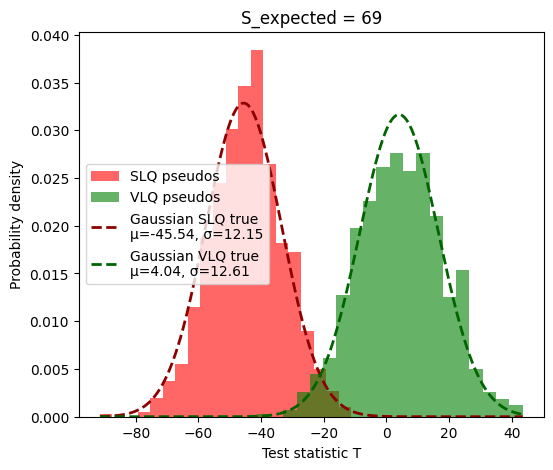

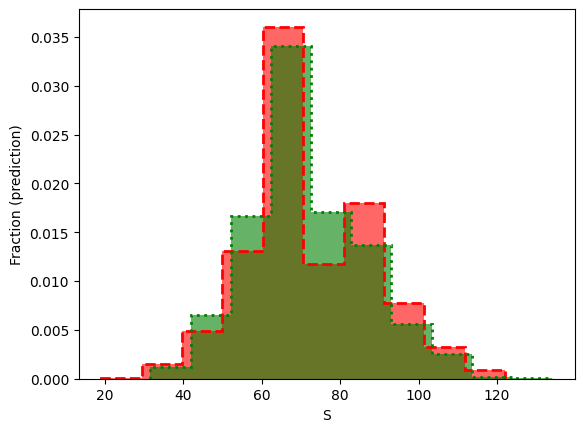

S mean SLQ:  73.05706453618835
S std SLQ:  15.479061872384293
S mean VLQ:  72.27216332084284
S std VLQ:  14.607883224333426


------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.901
1 = VLQ only : 0.013
2 = both     : 0.028
3 = neither  : 0.058

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.012
1 = VLQ only : 0.912
2 = both     : 0.029
3 = neither  : 0.047

------
 COMPARING WITH CONTINUOUS MASSES (interpolation) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.927
1 = VLQ only : 0.009
2 = both     : 0.019
3 = neither  : 0.045

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.011
1 = VLQ only : 0.924
2 = both     : 0.029
3 = neither  : 0.036

------
 COMPARING WITH THE PREVIOUSLY KNOWN PDF 
TESTING SLQ
Cl

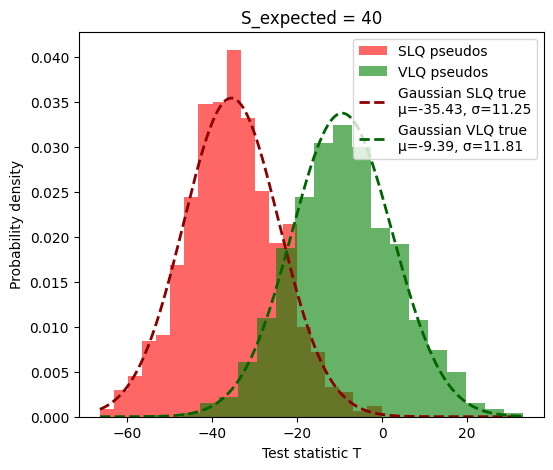

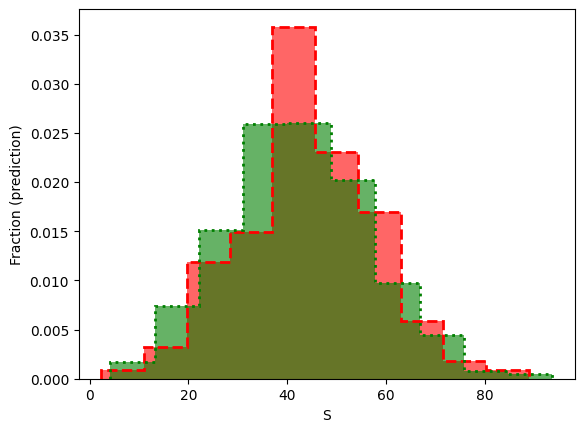

S mean SLQ:  43.402278610783775
S std SLQ:  13.75003633079932
S mean VLQ:  42.61017630883899
S std VLQ:  14.102052312193882


------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.59
1 = VLQ only : 0.035
2 = both     : 0.341
3 = neither  : 0.034

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.034
1 = VLQ only : 0.59
2 = both     : 0.341
3 = neither  : 0.035

------
 COMPARING WITH CONTINUOUS MASSES (interpolation) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.611
1 = VLQ only : 0.04
2 = both     : 0.329
3 = neither  : 0.02

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.038
1 = VLQ only : 0.607
2 = both     : 0.323
3 = neither  : 0.032

------
 COMPARING WITH THE PREVIOUSLY KNOWN PDF 
TESTING SLQ
Classi

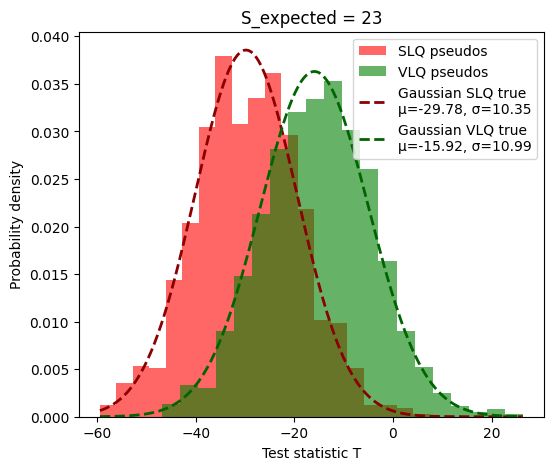

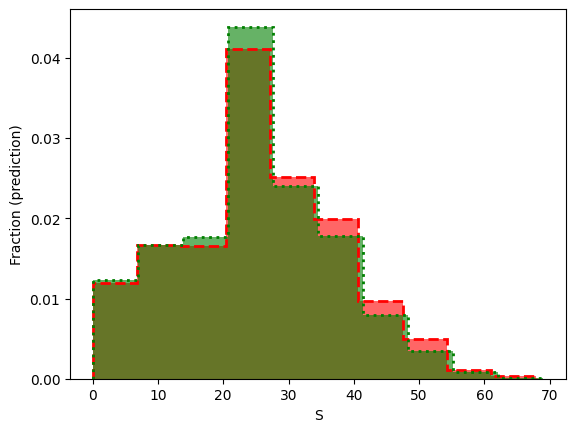

S mean SLQ:  24.99801911293385
S std SLQ:  12.549412583796439
S mean VLQ:  24.4094535677652
S std VLQ:  12.265833347521875


------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.259
1 = VLQ only : 0.034
2 = both     : 0.68
3 = neither  : 0.027

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.035
1 = VLQ only : 0.314
2 = both     : 0.628
3 = neither  : 0.023

------
 COMPARING WITH CONTINUOUS MASSES (interpolation) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.251
1 = VLQ only : 0.033
2 = both     : 0.69
3 = neither  : 0.026

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.03
1 = VLQ only : 0.279
2 = both     : 0.661
3 = neither  : 0.03

------
 COMPARING WITH THE PREVIOUSLY KNOWN PDF 
TESTING SLQ
Classif

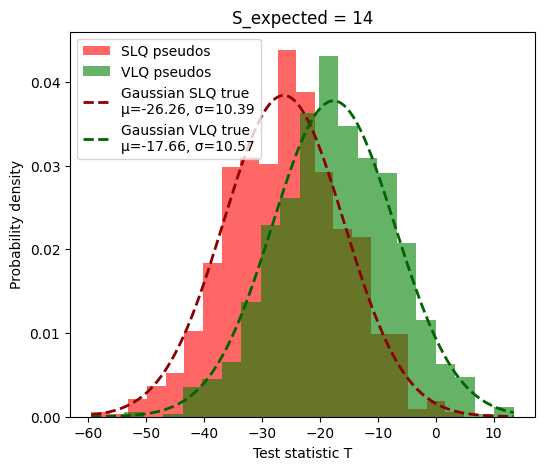

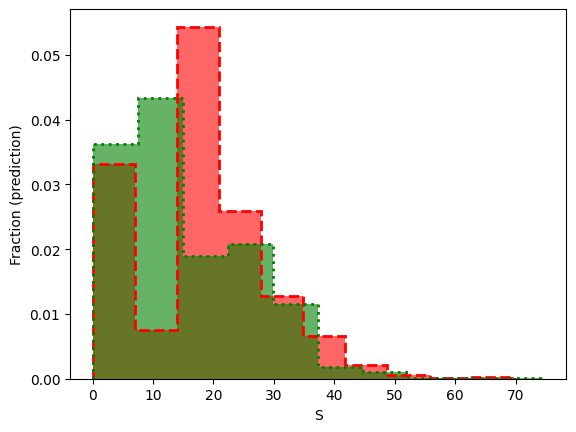

S mean SLQ:  16.607170634869338
S std SLQ:  11.453591237866501
S mean VLQ:  15.81157239213521
S std VLQ:  11.0237929034737


------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.123
1 = VLQ only : 0.04
2 = both     : 0.823
3 = neither  : 0.014

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.027
1 = VLQ only : 0.172
2 = both     : 0.784
3 = neither  : 0.017

------
 COMPARING WITH CONTINUOUS MASSES (interpolation) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.107
1 = VLQ only : 0.036
2 = both     : 0.836
3 = neither  : 0.021

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.025
1 = VLQ only : 0.121
2 = both     : 0.826
3 = neither  : 0.028

------
 COMPARING WITH THE PREVIOUSLY KNOWN PDF 
TESTING SLQ
Clas

In [46]:
Z_threshold = 1.96

n_pseudo = 1000

# benchmarks
classification_SLQ_BPOK = []
classification_VLQ_BPOK = []

# interpolate
classification_SLQ_inter = []
classification_VLQ_inter = []

# previously known PDFs
classification_SLQ_prev = []
classification_VLQ_prev = []


Z_SLQ_BPOK = []
Z_VLQ_BPOK = []

Z_SLQ_inter = []
Z_VLQ_inter = []

Z_SLQ_prev = []
Z_VLQ_prev = []


mu_TSLQ = []
std_TSLQ = []
mu_TVLQ = []
std_TVLQ = []



for ii_S, S_exp in enumerate(S_exp_SLQ):

    print("\n==========================")

    print("S_expected_SLQ =", S_exp_SLQ[ii_S])
    # print("S_expected_VLQ =", S_exp_VLQ[ii_S]) # same number of events


    # dado un S, le asigna la masa (del SLQ o VLQ) correspondiente
    mass_SLQ = m_SLQ[ii_S]
    mass_VLQ = m_VLQ[ii_S]
    print("mass_SLQ =", mass_SLQ, " GeV")
    print("mass_VLQ =", mass_VLQ, " GeV")


    # computamos el T statistic para todos los pseudo
    T_SLQ = []
    T_VLQ = []

    # compute the number of events
    muS_fits_SLQ = []
    muS_fits_VLQ = []


    for i in range(n_pseudo):

        N_B = np.random.poisson(B_expected)

        # indices of the events
        idx_B = np.random.choice(len(events_SM[:,0]), N_B)

        scoresA_B = events_SM[:,0][idx_B]
        scoresB_B = events_SM[:,1][idx_B]



        ###########
        # FOR SLQ #
        ###########

        N_S = np.random.poisson(S_exp_SLQ[ii_S])

        # indices of the events
        idx_S = np.random.choice(len(events_SLQ[mass_SLQ][:,0]), N_S)

        scoresA_S = events_SLQ[mass_SLQ][:,0][idx_S]


        data_scores = np.concatenate([scoresA_B, scoresA_S])

        hist_data, _ = np.histogram(data_scores, bins=bins)

        # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
        def neg_logL(params):
            mu_S, mu_B = params

            lambda_i = mu_S * pS + mu_B * pB
            lambda_i = np.clip(lambda_i, 1e-10, None)

            return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

        # 3) Minimizar
        result = minimize(
            neg_logL,
            x0=[S_exp, B_expected],
            bounds=[(0, None), (0, None)]
        )

        muS_fit, muB_fit = result.x

        muS_fits_SLQ.append(muS_fit)


        # the pseudo exp
        X_pseudo_S = df_SLQ_norm[mass_SLQ].loc[idx_S].values
        # add the S fitted
        X_pseudo_S = np.column_stack([X_pseudo_S, np.full(len(X_pseudo_S), muS_fit)])

        scoresB_S = classifier_spin.predict_proba(X_pseudo_S)[:,1]


        scoresA = np.concatenate([scoresA_B, scoresA_S])
        scoresB = np.concatenate([scoresB_B, scoresB_S])

        T = compute_test_statistic(scoresA, scoresB, threshold_A)

        T_SLQ.append(T)




        ###########
        # FOR VLQ #
        ###########

        N_S = np.random.poisson(S_exp_SLQ[ii_S]) # same number of events

        # indices of the events
        idx_S = np.random.choice(len(events_VLQ[mass_VLQ][:,0]), N_S)

        scoresA_S = events_VLQ[mass_VLQ][:,0][idx_S]


        data_scores = np.concatenate([scoresA_B, scoresA_S])

        hist_data, _ = np.histogram(data_scores, bins=bins)

        # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
        def neg_logL(params):
            mu_S, mu_B = params

            lambda_i = mu_S * pS + mu_B * pB
            lambda_i = np.clip(lambda_i, 1e-10, None)

            return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

        # 3) Minimizar
        result = minimize(
            neg_logL,
            x0=[S_exp, B_expected],
            bounds=[(0, None), (0, None)]
        )

        muS_fit, muB_fit = result.x

        muS_fits_VLQ.append(muS_fit)


        # the pseudo exp
        X_pseudo_V = df_VLQ_norm[mass_VLQ].loc[idx_S].values
        # add the S fitted
        X_pseudo_V = np.column_stack([X_pseudo_V, np.full(len(X_pseudo_V), muS_fit)])

        scoresB_S = classifier_spin.predict_proba(X_pseudo_V)[:,1]


        scoresA = np.concatenate([scoresA_B, scoresA_S])
        scoresB = np.concatenate([scoresB_B, scoresB_S])

        T = compute_test_statistic(scoresA, scoresB, threshold_A)

        T_VLQ.append(T)

    # Compute the characteristics of the psedo-experiment T distributions
    mu_TSLQ.append( np.mean(T_SLQ) )
    mu_TVLQ.append( np.mean(T_VLQ) )

    std_TSLQ.append( np.std(T_SLQ) )
    std_TVLQ.append( np.std(T_VLQ) )




    # rango común para plotear
    xmin = min(np.min(T_SLQ), np.min(T_VLQ))
    xmax = max(np.max(T_SLQ), np.max(T_VLQ))
    x = np.linspace(xmin, xmax, 500)

    # gaussianas
    gauss_S = (1/(sigma_S[ii_S]*np.sqrt(2*np.pi))) * np.exp(-(x - mu_S[ii_S])**2 / (2*sigma_S[ii_S]**2))
    gauss_V = (1/(sigma_V[ii_S]*np.sqrt(2*np.pi))) * np.exp(-(x - mu_V[ii_S])**2 / (2*sigma_V[ii_S]**2))


    # plot gaussian PDFs + pseudo-experiments (of the same sector) distributions
    plt.figure(figsize=(6,5))

    plt.hist(T_SLQ, bins=20, density=True, color='red', alpha=0.6, label="SLQ pseudos")
    plt.hist(T_VLQ, bins=20, density=True, color='green', alpha=0.6, label="VLQ pseudos")

    # gaussianas
    plt.plot(x, gauss_S, color='darkred', linewidth=2, linestyle='--', label=f"Gaussian SLQ true\nμ={mu_S[ii_S]:.2f}, σ={sigma_S[ii_S]:.2f}")
    plt.plot(x, gauss_V, color='darkgreen', linewidth=2, linestyle='--', label=f"Gaussian VLQ true\nμ={mu_V[ii_S]:.2f}, σ={sigma_V[ii_S]:.2f}")

    plt.xlabel("Test statistic T")
    plt.ylabel("Probability density")
    plt.title(f"S_expected = {S_exp}")
    plt.legend()

    plt.show()


    plt.hist(muS_fits_SLQ, bins=10, histtype='step', linestyle='--', edgecolor='red', linewidth=2, density=True)
    plt.hist(muS_fits_SLQ, bins=10, color='red', alpha=0.6, density=True)
    plt.hist(muS_fits_VLQ, bins=10, histtype='step', linestyle=':', edgecolor='green', linewidth=2, density=True)
    plt.hist(muS_fits_VLQ, bins=10, color='green', alpha=0.6, density=True)
    plt.xlabel("S")
    plt.ylabel("Fraction (prediction)")
    plt.show()

    print('S mean SLQ: ', np.mean(muS_fits_SLQ))
    print('S std SLQ: ', np.std(muS_fits_SLQ))
    print('S mean VLQ: ', np.mean(muS_fits_VLQ))
    print('S std VLQ: ', np.std(muS_fits_VLQ))
    print('')


    # COMPARING WITH DISCRETE MASS EXAMPLES (following S)

    # Vamos a clasificar cada pseudo
    # 0: SLQ
    # 1: VLQ
    # 2: compatible con ambos
    # 3: incompatible con ambos
    pred_counts_SLQ = [0,0,0,0]
    pred_counts_VLQ = [0,0,0,0]

    Z_SLQ_BPOK_step = []
    Z_VLQ_BPOK_step = []

    for i in range(n_pseudo):

        # TRUE: SLQ
        index_pseudo = search_bench(muS_fits_SLQ[i], S_mean_fit_both, S_std_fit_both )

        T_obs = T_SLQ[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(S_mean_fit_both[index_pseudo])) / f_sigma_S(S_mean_fit_both[index_pseudo])
        Z_VLQ_val = abs(T_obs - f_mu_V(S_mean_fit_both[index_pseudo])) / f_sigma_V(S_mean_fit_both[index_pseudo])

        Z_SLQ_BPOK_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_SLQ[pred] += 1


        # TRUE: VLQ
        index_pseudo = search_bench(muS_fits_VLQ[i], S_mean_fit_both, S_std_fit_both )

        T_obs = T_VLQ[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(S_mean_fit_both[index_pseudo])) / f_sigma_S(S_mean_fit_both[index_pseudo])
        Z_VLQ_val = abs(T_obs - f_mu_V(S_mean_fit_both[index_pseudo])) / f_sigma_V(S_mean_fit_both[index_pseudo])

        Z_VLQ_BPOK_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_VLQ[pred] += 1


    Z_SLQ_BPOK.append(np.array(Z_SLQ_BPOK_step))
    Z_VLQ_BPOK.append(np.array(Z_VLQ_BPOK_step))


    # SLQ
    pred_counts_SLQ = np.array(pred_counts_SLQ) / n_pseudo

    print("\n------")
    print(" COMPARING WITH DISCRETE MASS EXAMPLES (following S) ")

    print("TESTING SLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_SLQ[0])
    print("1 = VLQ only :", pred_counts_SLQ[1])
    print("2 = both     :", pred_counts_SLQ[2])
    print("3 = neither  :", pred_counts_SLQ[3])

    classification_SLQ_BPOK.append(pred_counts_SLQ)


    print('')

    # VLQ
    pred_counts_VLQ = np.array(pred_counts_VLQ) / n_pseudo

    print("TESTING VLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_VLQ[0])
    print("1 = VLQ only :", pred_counts_VLQ[1])
    print("2 = both     :", pred_counts_VLQ[2])
    print("3 = neither  :", pred_counts_VLQ[3])

    classification_VLQ_BPOK.append(pred_counts_VLQ)





    # COMPARING WITH CONTINUOUS MASSES (interpolation)

    # Vamos a clasificar cada pseudo
    # 0: SLQ
    # 1: VLQ
    # 2: compatible con ambos
    # 3: incompatible con ambos
    pred_counts_SLQ = [0,0,0,0]
    pred_counts_VLQ = [0,0,0,0]

    Z_SLQ_inter_step = []
    Z_VLQ_inter_step = []

    for i in range(n_pseudo):

        # TRUE: SLQ
        T_obs = T_SLQ[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(muS_fits_SLQ[i])) / f_sigma_S(muS_fits_SLQ[i])
        Z_VLQ_val = abs(T_obs - f_mu_V(muS_fits_SLQ[i])) / f_sigma_V(muS_fits_SLQ[i])

        Z_SLQ_inter_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_SLQ[pred] += 1


        # TRUE: VLQ
        T_obs = T_VLQ[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(muS_fits_VLQ[i])) / f_sigma_S(muS_fits_VLQ[i])
        Z_VLQ_val = abs(T_obs - f_mu_V(muS_fits_VLQ[i])) / f_sigma_V(muS_fits_VLQ[i])

        Z_VLQ_inter_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_VLQ[pred] += 1


    Z_SLQ_inter.append(np.array(Z_SLQ_inter_step))
    Z_VLQ_inter.append(np.array(Z_VLQ_inter_step))


    # SLQ
    pred_counts_SLQ = np.array(pred_counts_SLQ) / n_pseudo

    print("\n------")
    print(" COMPARING WITH CONTINUOUS MASSES (interpolation) ")

    print("TESTING SLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_SLQ[0])
    print("1 = VLQ only :", pred_counts_SLQ[1])
    print("2 = both     :", pred_counts_SLQ[2])
    print("3 = neither  :", pred_counts_SLQ[3])

    classification_SLQ_inter.append(pred_counts_SLQ)


    print('')

    # VLQ
    pred_counts_VLQ = np.array(pred_counts_VLQ) / n_pseudo

    print("TESTING VLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_VLQ[0])
    print("1 = VLQ only :", pred_counts_VLQ[1])
    print("2 = both     :", pred_counts_VLQ[2])
    print("3 = neither  :", pred_counts_VLQ[3])

    classification_VLQ_inter.append(pred_counts_VLQ)





    # COMPARING WITH THE PREVIOUSLY KNOWN PDF

    # Vamos a clasificar cada pseudo
    # 0: SLQ
    # 1: VLQ
    # 2: compatible con ambos
    # 3: incompatible con ambos
    pred_counts_SLQ = [0,0,0,0]
    pred_counts_VLQ = [0,0,0,0]

    Z_SLQ_prev_step = []
    Z_VLQ_prev_step = []

    for i in range(n_pseudo):

        # TRUE: SLQ
        T_obs = T_SLQ[i]

        Z_SLQ_val = abs(T_obs - mu_S[ii_S]) / sigma_S[ii_S]
        Z_VLQ_val = abs(T_obs - mu_V[ii_S]) / sigma_V[ii_S]

        Z_SLQ_prev_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_SLQ[pred] += 1


        # TRUE: VLQ
        T_obs = T_VLQ[i]

        Z_SLQ_val = abs(T_obs - mu_S[ii_S]) / sigma_S[ii_S]
        Z_VLQ_val = abs(T_obs - mu_V[ii_S]) / sigma_V[ii_S]

        Z_VLQ_prev_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_VLQ[pred] += 1


    Z_SLQ_prev.append(np.array(Z_SLQ_prev_step))
    Z_VLQ_prev.append(np.array(Z_VLQ_prev_step))


    # SLQ
    pred_counts_SLQ = np.array(pred_counts_SLQ) / n_pseudo

    print("\n------")
    print(" COMPARING WITH THE PREVIOUSLY KNOWN PDF ")

    print("TESTING SLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_SLQ[0])
    print("1 = VLQ only :", pred_counts_SLQ[1])
    print("2 = both     :", pred_counts_SLQ[2])
    print("3 = neither  :", pred_counts_SLQ[3])

    classification_SLQ_prev.append(pred_counts_SLQ)


    print('')

    # VLQ
    pred_counts_VLQ = np.array(pred_counts_VLQ) / n_pseudo

    print("TESTING VLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_VLQ[0])
    print("1 = VLQ only :", pred_counts_VLQ[1])
    print("2 = both     :", pred_counts_VLQ[2])
    print("3 = neither  :", pred_counts_VLQ[3])

    classification_VLQ_prev.append(pred_counts_VLQ)


5 sigmas:
Benchmarks
SLQ mass:  1549.6496496496497 [GeV]      ( 1511.8118118118118 - 1593.7937937937938 )
VLQ mass:  1969.96996996997 [GeV]      ( 1925.8258258258259 - 2023.2232232232232 )

Interpolated
SLQ mass:  1551.7517517517517 [GeV]      ( 1511.8118118118118 - 1593.7937937937938 )
VLQ mass:  1970.6706706706707 [GeV]      ( 1924.4244244244244 - 2023.923923923924 )

Known PDF
SLQ mass:  1547.5475475475475 [GeV]      ( 1511.111111111111 - 1588.888888888889 )
VLQ mass:  1968.5685685685685 [GeV]      ( 1926.5265265265266 - 2015.5155155155155 )


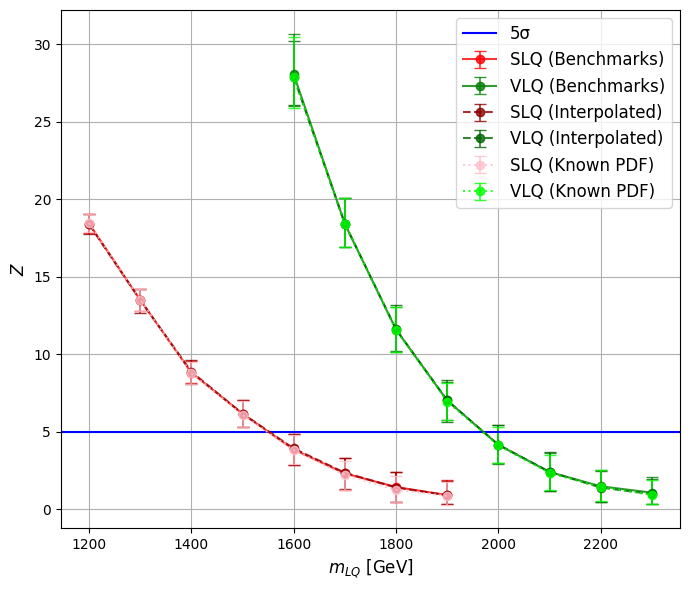

In [47]:

def Z_processor(lista_Z, select):
    """computes the median and error (percentiles 16 y 84)
    select = 1 ---> SLQ (true) vs VLQ
    select = 0 ---> VLQ (true) vs SLQ
    """
    medians = []
    err_inf = []
    err_sup = []

    for z_matriz in lista_Z:
        z_valores = z_matriz[:, select]
        med = np.median(z_valores)
        p16 = np.percentile(z_valores, 16)
        p84 = np.percentile(z_valores, 84)

        medians.append(med)
        err_inf.append(med - p16)  # percentile
        err_sup.append(p84 - med)  # percentile

    return np.array(medians), [np.array(err_inf), np.array(err_sup)]

# Compute
z_BPOK_SLQ, err_BPOK_SLQ = Z_processor(Z_SLQ_BPOK, select=1)
z_BPOK_VLQ, err_BPOK_VLQ = Z_processor(Z_VLQ_BPOK, select=0)
z_inter_SLQ, err_inter_SLQ = Z_processor(Z_SLQ_inter, select=1)
z_inter_VLQ, err_inter_VLQ = Z_processor(Z_VLQ_inter, select=0)
z_prev_SLQ, err_prev_SLQ = Z_processor(Z_SLQ_prev, select=1)
z_prev_VLQ, err_prev_VLQ = Z_processor(Z_VLQ_prev, select=0)



# Interpolate to find Z=5
def find_mass(mass_array, z_med, err_list, z_target=5.0):
    """Interpolate the mass and find the error, 1-sigma"""
    if np.max(z_med) < z_target and np.min(z_med) < z_target:
        return None, None, None # Z is not in this range

    # mass grid
    grid_masas = np.linspace(mass_array.min(), mass_array.max(), 1000)

    # curves
    z_sup_valores = z_med + err_list[1] # Median + err_sup (percentil 84)
    z_inf_valores = z_med - err_list[0] # Median - err_inf (percentil 16)

    f_med = interp1d(mass_array, z_med, kind='linear', bounds_error=False, fill_value="extrapolate")
    f_sup = interp1d(mass_array, z_sup_valores, kind='linear', bounds_error=False, fill_value="extrapolate")
    f_inf = interp1d(mass_array, z_inf_valores, kind='linear', bounds_error=False, fill_value="extrapolate")

    # search for Z = z_target
    m5_central = grid_masas[np.argmin(np.abs(f_med(grid_masas) - z_target))]
    m5_inf     = grid_masas[np.argmin(np.abs(f_inf(grid_masas) - z_target))]
    m5_sup     = grid_masas[np.argmin(np.abs(f_sup(grid_masas) - z_target))]

    return m5_central, m5_inf, m5_sup

# Compute
m5_BPOK_SLQ, m5_BPOK_SLQ_inf, m5_BPOK_SLQ_sup = find_mass(np.array(m_SLQ), z_BPOK_SLQ, err_BPOK_SLQ)
m5_BPOK_VLQ, m5_BPOK_VLQ_inf, m5_BPOK_VLQ_sup = find_mass(np.array(m_VLQ), z_BPOK_VLQ, err_BPOK_VLQ)
m5_inter_SLQ, m5_inter_SLQ_inf, m5_inter_SLQ_sup = find_mass(np.array(m_SLQ), z_inter_SLQ, err_inter_SLQ)
m5_inter_VLQ, m5_inter_VLQ_inf, m5_inter_VLQ_sup = find_mass(np.array(m_VLQ), z_inter_VLQ, err_inter_VLQ)
m5_prev_SLQ, m5_prev_SLQ_inf, m5_prev_SLQ_sup = find_mass(np.array(m_SLQ), z_prev_SLQ, err_prev_SLQ)
m5_prev_VLQ, m5_prev_VLQ_inf, m5_prev_VLQ_sup = find_mass(np.array(m_VLQ), z_prev_VLQ, err_prev_VLQ)


# Print
print('5 sigmas:')
print('Benchmarks')
print('SLQ mass: ', m5_BPOK_SLQ, '[GeV]      (', m5_BPOK_SLQ_inf, '-', m5_BPOK_SLQ_sup, ')')
print('VLQ mass: ', m5_BPOK_VLQ, '[GeV]      (', m5_BPOK_VLQ_inf, '-', m5_BPOK_VLQ_sup, ')')
print('\nInterpolated')
print('SLQ mass: ', m5_inter_SLQ, '[GeV]      (', m5_inter_SLQ_inf, '-', m5_inter_SLQ_sup, ')')
print('VLQ mass: ', m5_inter_VLQ, '[GeV]      (', m5_inter_VLQ_inf, '-', m5_inter_VLQ_sup, ')')
print('\nKnown PDF')
print('SLQ mass: ', m5_prev_SLQ, '[GeV]      (', m5_prev_SLQ_inf, '-', m5_prev_SLQ_sup, ')')
print('VLQ mass: ', m5_prev_VLQ, '[GeV]      (', m5_prev_VLQ_inf, '-', m5_prev_VLQ_sup, ')')


# PLOT
plt.figure(figsize=(7, 6))

plt.errorbar(m_SLQ, z_BPOK_SLQ, yerr=err_BPOK_SLQ, color='red', linestyle='-', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label='SLQ (Benchmarks)')
plt.errorbar(m_VLQ, z_BPOK_VLQ, yerr=err_BPOK_VLQ, color='green', linestyle='-', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label='VLQ (Benchmarks)')
plt.errorbar(m_SLQ, z_inter_SLQ, yerr=err_inter_SLQ, color='darkred', linestyle='--', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label='SLQ (Interpolated)')
plt.errorbar(m_VLQ, z_inter_VLQ, yerr=err_inter_VLQ, color='darkgreen', linestyle='--', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label='VLQ (Interpolated)')
plt.errorbar(m_SLQ, z_prev_SLQ, yerr=err_prev_SLQ, color='pink', linestyle=':', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label='SLQ (Known PDF)')
plt.errorbar(m_VLQ, z_prev_VLQ, yerr=err_prev_VLQ, color='lime', linestyle=':', marker='o', capsize=4, elinewidth=1.2, alpha=0.8, label='VLQ (Known PDF)')

plt.axhline(y=5.0, color='blue', linestyle='-', linewidth=1.5, label='5σ')

# plt.ylim(0, 25)
plt.xlabel(r"$m_{LQ}$ [GeV]", fontsize=12)
plt.ylabel(r"$Z$", fontsize=12)
plt.grid(True)
plt.legend(fontsize=12, loc='upper right')
plt.tight_layout()
plt.show()

In [48]:
class_SLQ_BPOK_array = np.array(classification_SLQ_BPOK) # Forma (N, 4)
class_VLQ_BPOK_array = np.array(classification_VLQ_BPOK) # Forma (N, 4)

class_SLQ_inter_array = np.array(classification_SLQ_inter) # Forma (N, 4)
class_VLQ_inter_array = np.array(classification_VLQ_inter) # Forma (N, 4)

class_SLQ_prev_array = np.array(classification_SLQ_prev) # Forma (N, 4)
class_VLQ_prev_array = np.array(classification_VLQ_prev) # Forma (N, 4)

# SAVE

file_path = mainfolder + 'saved-results/vs14TeV_err_beta09.txt'

# Combine all data into a single array
data_to_save = np.column_stack([
    S_expected_SLQ[2:],
    m_SLQ,
    m_VLQ,
    mu_S,
    sigma_S,
    mu_V,
    sigma_V,
    mu_TSLQ,
    std_TSLQ,
    mu_TVLQ,
    std_TVLQ,
    class_SLQ_BPOK_array,
    class_VLQ_BPOK_array,
    class_SLQ_inter_array,
    class_VLQ_inter_array,
    class_SLQ_prev_array,
    class_VLQ_prev_array,
    z_BPOK_SLQ,
    err_BPOK_SLQ[0],
    err_BPOK_SLQ[1],
    z_BPOK_VLQ,
    err_BPOK_VLQ[0],
    err_BPOK_VLQ[1],
    z_inter_SLQ,
    err_inter_SLQ[0],
    err_inter_SLQ[1],
    z_inter_VLQ,
    err_inter_VLQ[0],
    err_inter_VLQ[1],
    z_prev_SLQ,
    err_prev_SLQ[0],
    err_prev_SLQ[1],
    z_prev_VLQ,
    err_prev_VLQ[0],
    err_prev_VLQ[1],
])

# Save data to a text file
np.savetxt(file_path, data_to_save, fmt='%.6f',
           header='# S_expected mass_list_SLQ mass_list_SLQ mu_S sigma_S mu_V sigma_V mu_TSLQ std_TSLQ mu_TVLQ std_TVLQ classification_SLQ classification_VLQ',
           comments='')

print(f"Data saved to: {file_path}")

Data saved to: /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/03-pythons2026-junio/saved-results/vs14TeV_err_beta09.txt


In [49]:
# LOAD

file_path = mainfolder + 'saved-results/vs14TeV_err_beta09.txt'

loaded_data = np.loadtxt(file_path)

S_expected = loaded_data[:, 0]
mass_list_SLQ = loaded_data[:, 1]
mass_list_VLQ = loaded_data[:, 2]
mu_S = loaded_data[:, 3]
sigma_S = loaded_data[:, 4]
mu_V = loaded_data[:, 5]
sigma_V = loaded_data[:, 6]
mu_TSLQ = loaded_data[:, 7]
std_TSLQ = loaded_data[:, 8]
mu_TVLQ = loaded_data[:, 9]
std_TVLQ = loaded_data[:, 10]
classification_SLQ_BPOK = loaded_data[:, 11:15]
classification_VLQ_BPOK = loaded_data[:, 15:19]
classification_SLQ_inter = loaded_data[:, 19:23]
classification_VLQ_inter = loaded_data[:, 23:27]
classification_SLQ_prev = loaded_data[:, 27:31]
classification_VLQ_prev = loaded_data[:, 31:35]
z_BPOK_SLQ = loaded_data[:, 35]
err_BPOK_SLQ = np.concatenate([loaded_data[:, 36], loaded_data[:, 37]])
z_BPOK_VLQ = loaded_data[:, 38]
err_BPOK_VLQ = np.concatenate([loaded_data[:, 39], loaded_data[:, 40]])
z_inter_SLQ = loaded_data[:, 41]
err_inter_SLQ = np.concatenate([loaded_data[:, 42], loaded_data[:, 43]])
z_inter_VLQ = loaded_data[:, 44]
err_inter_VLQ = np.concatenate([loaded_data[:, 45], loaded_data[:, 46]])
z_prev_SLQ = loaded_data[:, 47]
err_prev_SLQ = np.concatenate([loaded_data[:, 48], loaded_data[:, 49]])
z_prev_VLQ = loaded_data[:, 50]
err_prev_VLQ = np.concatenate([loaded_data[:, 51], loaded_data[:, 52]])





n_pseudo_TRUE = 1000
threshold_A = 0.95

print('n_pseudo_TRUE: ', n_pseudo_TRUE)
print('threshold_A: ', threshold_A)

n_pseudo_TRUE:  1000
threshold_A:  0.95


In [50]:
# Interpolate to find Z=5
def find_mass(mass_array, z_med, err_list, z_target=5.0):
    """Interpolate the mass and find the error, 1-sigma"""
    if np.max(z_med) < z_target and np.min(z_med) < z_target:
        return None, None, None # Z is not in this range

    # mass grid
    grid_masas = np.linspace(mass_array.min(), mass_array.max(), 1000)

    # curves
    z_sup_valores = z_med + err_list[1] # Median + err_sup (percentil 84)
    z_inf_valores = z_med - err_list[0] # Median - err_inf (percentil 16)

    f_med = interp1d(mass_array, z_med, kind='linear', bounds_error=False, fill_value="extrapolate")
    f_sup = interp1d(mass_array, z_sup_valores, kind='linear', bounds_error=False, fill_value="extrapolate")
    f_inf = interp1d(mass_array, z_inf_valores, kind='linear', bounds_error=False, fill_value="extrapolate")

    # search for Z = z_target
    m5_central = grid_masas[np.argmin(np.abs(f_med(grid_masas) - z_target))]
    m5_inf     = grid_masas[np.argmin(np.abs(f_inf(grid_masas) - z_target))]
    m5_sup     = grid_masas[np.argmin(np.abs(f_sup(grid_masas) - z_target))]

    return m5_central, m5_inf, m5_sup

# Compute
m5_BPOK_SLQ, m5_BPOK_SLQ_inf, m5_BPOK_SLQ_sup = find_mass(np.array(mass_list_SLQ), z_BPOK_SLQ, err_BPOK_SLQ, z_target=5.0)
m5_BPOK_VLQ, m5_BPOK_VLQ_inf, m5_BPOK_VLQ_sup = find_mass(np.array(mass_list_VLQ), z_BPOK_VLQ, err_BPOK_VLQ, z_target=5.0)
m5_inter_SLQ, m5_inter_SLQ_inf, m5_inter_SLQ_sup = find_mass(np.array(mass_list_SLQ), z_inter_SLQ, err_inter_SLQ, z_target=5.0)
m5_inter_VLQ, m5_inter_VLQ_inf, m5_inter_VLQ_sup = find_mass(np.array(mass_list_VLQ), z_inter_VLQ, err_inter_VLQ, z_target=5.0)
m5_prev_SLQ, m5_prev_SLQ_inf, m5_prev_SLQ_sup = find_mass(np.array(mass_list_SLQ), z_prev_SLQ, err_prev_SLQ, z_target=5.0)
m5_prev_VLQ, m5_prev_VLQ_inf, m5_prev_VLQ_sup = find_mass(np.array(mass_list_VLQ), z_prev_VLQ, err_prev_VLQ, z_target=5.0)

# Print
print('5 sigmas:')
print('Benchmarks')
print('SLQ mass: ', m5_BPOK_SLQ, '[GeV]      (', m5_BPOK_SLQ_inf, '-', m5_BPOK_SLQ_sup, ')')
print('VLQ mass: ', m5_BPOK_VLQ, '[GeV]      (', m5_BPOK_VLQ_inf, '-', m5_BPOK_VLQ_sup, ')')
print('\nInterpolated')
print('SLQ mass: ', m5_inter_SLQ, '[GeV]      (', m5_inter_SLQ_inf, '-', m5_inter_SLQ_sup, ')')
print('VLQ mass: ', m5_inter_VLQ, '[GeV]      (', m5_inter_VLQ_inf, '-', m5_inter_VLQ_sup, ')')
print('\nKnown PDF')
print('SLQ mass: ', m5_prev_SLQ, '[GeV]      (', m5_prev_SLQ_inf, '-', m5_prev_SLQ_sup, ')')
print('VLQ mass: ', m5_prev_VLQ, '[GeV]      (', m5_prev_VLQ_inf, '-', m5_prev_VLQ_sup, ')')

5 sigmas:
Benchmarks
SLQ mass:  1549.6496496496497 [GeV]      ( 1523.0230230230231 - 1581.8818818818818 )
VLQ mass:  1969.96996996997 [GeV]      ( 1899.1991991991993 - 2037.2372372372372 )

Interpolated
SLQ mass:  1551.7517517517517 [GeV]      ( 1522.3223223223222 - 1587.4874874874874 )
VLQ mass:  1970.6706706706707 [GeV]      ( 1906.2062062062062 - 2037.2372372372372 )

Known PDF
SLQ mass:  1547.5475475475475 [GeV]      ( 1520.920920920921 - 1579.7797797797798 )
VLQ mass:  1968.5685685685685 [GeV]      ( 1898.4984984984985 - 2033.7337337337337 )


In [51]:
# LOAD

file_path = mainfolder + 'saved-results/Z13TeV_err.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_13TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_13TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_13TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_13TeV = loaded_data[:, 4]
m_BL_exc_SLQ_13TeV = loaded_data[:, 5]
m_BL_dis_SLQ_13TeV = loaded_data[:, 6]
m_BL_exc_VLQ_13TeV = loaded_data[:, 7]
m_BL_dis_VLQ_13TeV = loaded_data[:, 8]
m_BL_exc_SLQ_low_13TeV = loaded_data[:, 9]
m_BL_dis_SLQ_low_13TeV = loaded_data[:, 10]
m_BL_exc_VLQ_low_13TeV = loaded_data[:, 11]
m_BL_dis_VLQ_low_13TeV = loaded_data[:, 12]
m_BL_exc_SLQ_high_13TeV = loaded_data[:, 13]
m_BL_dis_SLQ_high_13TeV = loaded_data[:, 14]
m_BL_exc_VLQ_high_13TeV = loaded_data[:, 15]
m_BL_dis_VLQ_high_13TeV = loaded_data[:, 16]


# LOAD

file_path = mainfolder + 'saved-results/Z136TeV_err.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_136TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_136TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_136TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_136TeV = loaded_data[:, 4]
m_BL_exc_SLQ_136TeV = loaded_data[:, 5]
m_BL_dis_SLQ_136TeV = loaded_data[:, 6]
m_BL_exc_VLQ_136TeV = loaded_data[:, 7]
m_BL_dis_VLQ_136TeV = loaded_data[:, 8]
m_BL_exc_SLQ_low_136TeV = loaded_data[:, 9]
m_BL_dis_SLQ_low_136TeV = loaded_data[:, 10]
m_BL_exc_VLQ_low_136TeV = loaded_data[:, 11]
m_BL_dis_VLQ_low_136TeV = loaded_data[:, 12]
m_BL_exc_SLQ_high_136TeV = loaded_data[:, 13]
m_BL_dis_SLQ_high_136TeV = loaded_data[:, 14]
m_BL_exc_VLQ_high_136TeV = loaded_data[:, 15]
m_BL_dis_VLQ_high_136TeV = loaded_data[:, 16]




# LOAD

file_path = mainfolder + 'saved-results/Z14TeV_err.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_14TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_14TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_14TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_14TeV = loaded_data[:, 4]
m_BL_exc_SLQ_14TeV = loaded_data[:, 5]
m_BL_dis_SLQ_14TeV = loaded_data[:, 6]
m_BL_exc_VLQ_14TeV = loaded_data[:, 7]
m_BL_dis_VLQ_14TeV = loaded_data[:, 8]
m_BL_exc_SLQ_low_14TeV = loaded_data[:, 9]
m_BL_dis_SLQ_low_14TeV = loaded_data[:, 10]
m_BL_exc_VLQ_low_14TeV = loaded_data[:, 11]
m_BL_dis_VLQ_low_14TeV = loaded_data[:, 12]
m_BL_exc_SLQ_high_14TeV = loaded_data[:, 13]
m_BL_dis_SLQ_high_14TeV = loaded_data[:, 14]
m_BL_exc_VLQ_high_14TeV = loaded_data[:, 15]
m_BL_dis_VLQ_high_14TeV = loaded_data[:, 16]

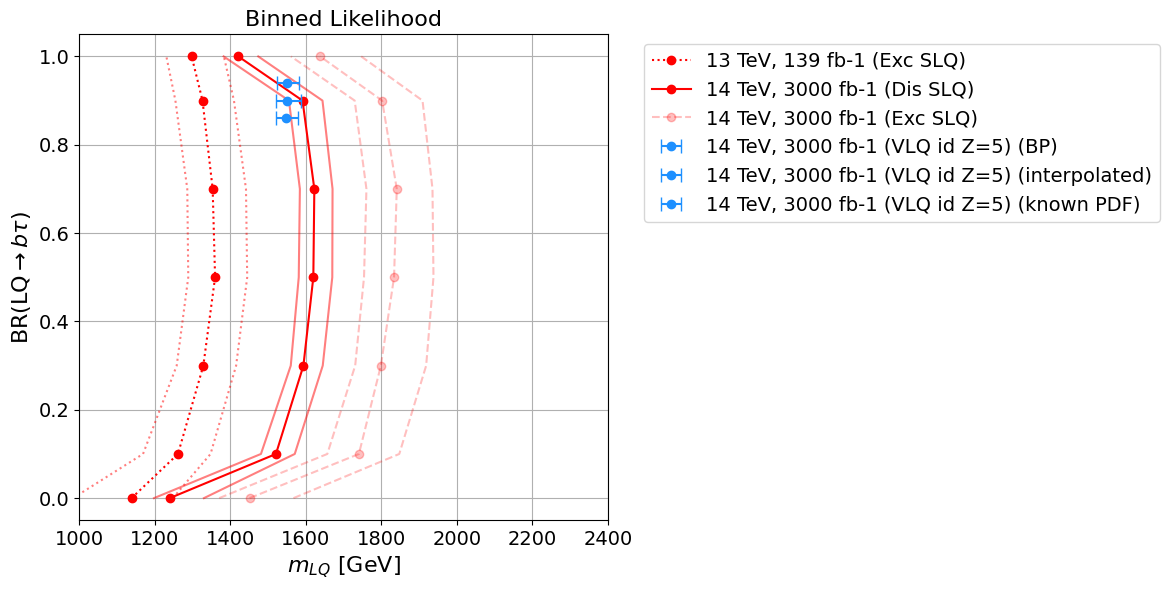

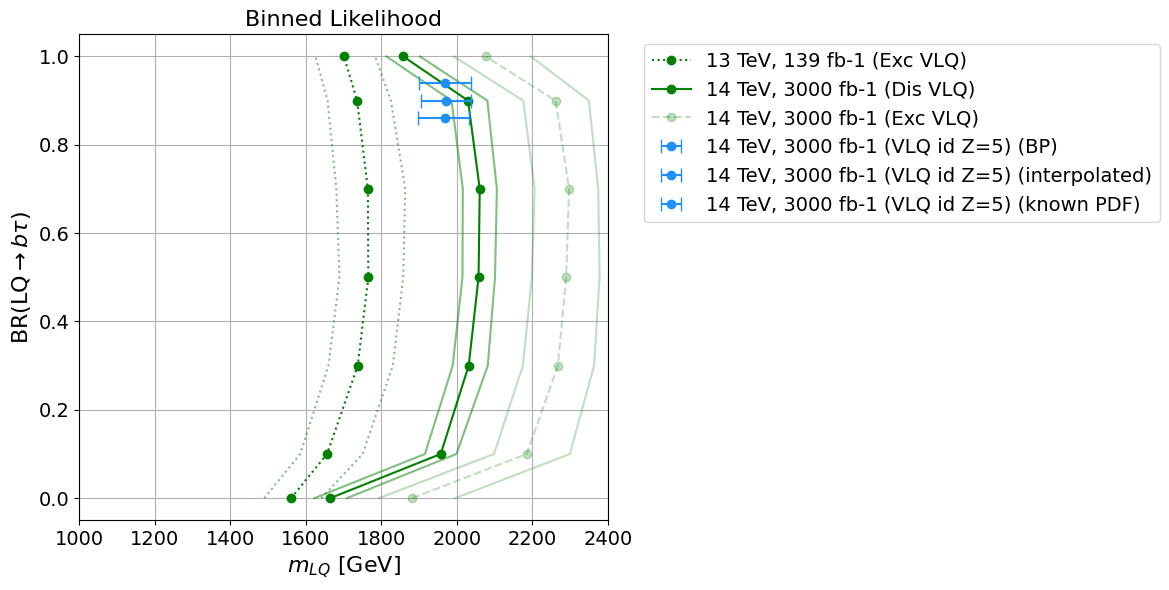

In [52]:

# plot BINNED LIKEHOOD

plt.figure(figsize=(12, 6))

plt.plot(m_BL_exc_SLQ_13TeV, betas, 'o:', c='red', label='13 TeV, 139 fb-1 (Exc SLQ)')
plt.plot(m_BL_exc_SLQ_low_13TeV, betas, ':', c='red', alpha=0.5)
plt.plot(m_BL_exc_SLQ_high_13TeV, betas, ':', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_14TeV, betas, 'o-', c='red', label='14 TeV, 3000 fb-1 (Dis SLQ)')
plt.plot(m_BL_dis_SLQ_low_14TeV, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_high_14TeV, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_exc_SLQ_14TeV, betas, 'o--', c='red', alpha=0.25, label='14 TeV, 3000 fb-1 (Exc SLQ)')
plt.plot(m_BL_exc_SLQ_low_14TeV, betas, '--', c='red', alpha=0.25)
plt.plot(m_BL_exc_SLQ_high_14TeV, betas, '--', c='red', alpha=0.25)


# benchmarks
m_SLQ_T_Z5 = [[m5_BPOK_SLQ - m5_BPOK_SLQ_inf], [m5_BPOK_SLQ_sup - m5_BPOK_SLQ]]
plt.errorbar(m5_BPOK_SLQ, 0.94, xerr=m_SLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='14 TeV, 3000 fb-1 (SLQ id Z=5) (BP)')

# interpolated
m_SLQ_T_Z5 = [[m5_inter_SLQ - m5_inter_SLQ_inf], [m5_inter_SLQ_sup - m5_inter_SLQ]]
plt.errorbar(m5_inter_SLQ, 0.9, xerr=m_SLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='14 TeV, 3000 fb-1 (SLQ id Z=5) (interpolated)')

# known pdf
m_SLQ_T_Z5 = [[m5_prev_SLQ - m5_prev_SLQ_inf], [m5_prev_SLQ_sup - m5_prev_SLQ]]
plt.errorbar(m5_prev_SLQ, 0.86, xerr=m_SLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='14 TeV, 3000 fb-1 (SLQ id Z=5) (known PDF)')


# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(1000,2400)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()





plt.figure(figsize=(12, 6))

plt.plot(m_BL_exc_VLQ_13TeV, betas, 'o:', c='green', label='13 TeV, 139 fb-1 (Exc VLQ)')
plt.plot(m_BL_exc_VLQ_low_13TeV, betas, ':', c='green', alpha=0.5)
plt.plot(m_BL_exc_VLQ_high_13TeV, betas, ':', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_14TeV, betas, 'o-', c='green', label='14 TeV, 3000 fb-1 (Dis VLQ)')
plt.plot(m_BL_dis_VLQ_low_14TeV, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_high_14TeV, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_exc_VLQ_14TeV, betas, 'o--', c='green', alpha=0.25, label='14 TeV, 3000 fb-1 (Exc VLQ)')
plt.plot(m_BL_exc_VLQ_low_14TeV, betas, '-', c='green', alpha=0.25)
plt.plot(m_BL_exc_VLQ_high_14TeV, betas, '-', c='green', alpha=0.25)


# benchmarks
m_VLQ_T_Z5 = [[m5_BPOK_VLQ - m5_BPOK_VLQ_inf], [m5_BPOK_VLQ_sup - m5_BPOK_VLQ]]
plt.errorbar(m5_BPOK_VLQ, 0.94, xerr=m_VLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='14 TeV, 3000 fb-1 (VLQ id Z=5) (BP)')

# interpolated
m_VLQ_T_Z5 = [[m5_inter_VLQ - m5_inter_VLQ_inf], [m5_inter_VLQ_sup - m5_inter_VLQ]]
plt.errorbar(m5_inter_VLQ, 0.9, xerr=m_VLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='14 TeV, 3000 fb-1 (VLQ id Z=5) (interpolated)')

# knwon pdf
m_VLQ_T_Z5 = [[m5_prev_VLQ - m5_prev_VLQ_inf], [m5_prev_VLQ_sup - m5_prev_VLQ]]
plt.errorbar(m5_prev_VLQ, 0.86, xerr=m_VLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='14 TeV, 3000 fb-1 (VLQ id Z=5) (known PDF)')


# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(1000,2400)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()